# <center>🏥 LABORATORIO N° 07</center>
## <center>Minería de Datos</center>
### <center>Clasificación Supervisada con Múltiples Modelos</center>
#### <center>Árbol de Decisión · Random Forest · k-NN · Regresión Logística · SVM</center>

---

| | |
|---|---|
| **Curso** | Minería de Datos |
| **Docente** | Pilar Rocío Sayán Mejía |
| **Semestre** | 2026-I |
| **Semana** | 7 — Cierre Unidades 1 y 2 |
| **Modalidad** | Virtual — Google Colab |
| **Entorno** | Python 3.x · scikit-learn · imbalanced-learn |

---

## 📋 CASO DE ESTUDIO: Hospital Vida Sana
### *Predicción de Recurrencia del Cáncer de Mama mediante Modelos de Clasificación Supervisada*

---

### 🏢 Contexto del Caso

El **Hospital Oncológico Vida Sana** es una institución médica de referencia en Lima, Perú, que atiende
anualmente a más de 2 000 pacientes con diagnóstico de cáncer de mama. El equipo médico enfrenta un
desafío crítico: **predecir si una paciente experimentará recurrencia del cáncer** tras recibir el
tratamiento inicial (cirugía, radioterapia o quimioterapia).

Actualmente, esta predicción depende exclusivamente del criterio clínico de los especialistas, lo que
genera inconsistencias en el seguimiento, altos costos hospitalarios y, en algunos casos, detección tardía
de recaídas que comprometen la vida de las pacientes.

---

### 🎯 Tu Rol: Analista de Datos

> **Eres el Analista de Datos Senior contratado por el Dr. Carlos Mendoza, Director Médico (CEO) del
> Hospital Vida Sana.** Tu misión es construir, comparar y recomendar el modelo de clasificación
> supervisada más adecuado para predecir la recurrencia del cáncer de mama, utilizando datos históricos
> de 286 pacientes del registro clínico del hospital.

---

### 🔬 Objetivo de Investigación General

Construir y comparar cinco modelos de clasificación supervisada (Árbol de Decisión, Random Forest, k-NN,
Regresión Logística y SVM) sobre el dataset de Breast Cancer (UCI) para predecir la **recurrencia del
cáncer de mama**, seleccionando el modelo óptimo para su implementación clínica.

### 📌 Objetivos Específicos

1. Realizar un análisis exploratorio del dataset, identificando el desbalanceo de clases y las variables categóricas.
2. Aplicar **One-Hot Encoding** a las variables cualitativas, definiendo correctamente la variable de referencia.
3. Implementar técnicas de manejo de desbalanceo: **SMOTE** y `class_weight='balanced'`.
4. Entrenar y optimizar los 5 modelos usando **GridSearchCV** con validación cruzada estratificada.
5. Interpretar los coeficientes de **Regresión Logística** mediante Odds Ratios.
6. Comparar los modelos con métricas apropiadas para clases desbalanceadas (F1-macro, AUC-ROC).
7. Emitir una **recomendación fundamentada** al Director Médico sobre el modelo a implementar.

---

## I. 🔒 SEGURIDAD

### Normas Generales
- No manipular hardware sin supervisión del docente.
- No ingerir alimentos ni bebidas durante la sesión de laboratorio.
- Guardar el trabajo periódicamente para evitar pérdida de datos.
- Al finalizar, limpiar y organizar el espacio de trabajo virtual.

### Normas Específicas — Datos Clínicos y Éticas de IA
- Los datos utilizados en este laboratorio son **anonimizados** (UCI ML Repository). Está prohibido
  intentar re-identificar a los pacientes.
- Los modelos predictivos en salud deben validarse clínicamente antes de su uso real.
  Este laboratorio tiene **fines exclusivamente educativos**.
- Priorizar métricas de **Recall** (sensibilidad) sobre Accuracy en diagnósticos médicos:
  un falso negativo (no detectar una recurrencia real) tiene mayor costo clínico que un falso positivo.
- Todo modelo de IA en salud debe ser transparente e interpretable para el equipo médico.

---

## II. 📚 FUNDAMENTO TEÓRICO

### 2.1 Árbol de Decisión (Decision Tree)
Un Árbol de Decisión divide el espacio de características de forma recursiva usando **criterios de
impureza** (Gini o Entropía). Cada nodo interno representa una pregunta sobre una variable; las hojas
representan la clase predicha.

| Hiperparámetro | Descripción |
|---|---|
| `max_depth` | Profundidad máxima del árbol (controla sobreajuste) |
| `min_samples_split` | Mínimo de muestras para dividir un nodo |
| `criterion` | Función de impureza: `gini` o `entropy` |

**Fórmula de Entropía:** $H = -\sum_{k} p_k \log_2(p_k)$

---

### 2.2 Random Forest
Ensemble de múltiples árboles de decisión entrenados con **bagging** (Bootstrap Aggregating).
Cada árbol usa una muestra aleatoria de datos y variables. La predicción final es por **mayoría de votos**.

| Hiperparámetro | Descripción |
|---|---|
| `n_estimators` | Número de árboles en el bosque |
| `max_depth` | Profundidad máxima de cada árbol |
| `max_features` | Nro. de variables a considerar en cada split |

**Ventaja clave:** Proporciona `feature_importances_` para identificar las variables más predictivas.

---

### 2.3 k-Vecinos más Cercanos (k-NN)
Algoritmo no paramétrico que clasifica una muestra basándose en las **k muestras más cercanas** en el
espacio de características. La clase asignada es la más frecuente entre los k vecinos.

$$d_{euclidiana}(x, x') = \sqrt{\sum_{i=1}^{n}(x_i - x'_i)^2}$$

⚠️ **Requiere escalado** de variables — sensible a la escala de las features.

| Hiperparámetro | Descripción |
|---|---|
| `n_neighbors` (K) | Número de vecinos a considerar |
| `weights` | `uniform` (todos iguales) o `distance` (ponderado por distancia) |
| `metric` | Función de distancia: `euclidean`, `manhattan`, `minkowski` |

---

### 2.4 Regresión Logística
Modelo de clasificación basado en la **función sigmoide** que estima la probabilidad de pertenencia
a una clase:

$$P(Y=1|X) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 X_1 + \cdots + \beta_p X_p)}}$$

**Odds Ratio (OR):** $OR_j = e^{\beta_j}$ — Interpretación:
- $OR > 1$: La variable aumenta la probabilidad de recurrencia respecto a la categoría de referencia.
- $OR < 1$: La variable reduce la probabilidad de recurrencia respecto a la categoría de referencia.
- $OR = 1$: Sin efecto.

**Variable de referencia (One-Hot Encoding con `drop_first=True`):**
Al aplicar OHE y eliminar la primera categoría, ésta se convierte en la **categoría de referencia**.
Todos los coeficientes se interpretan *en relación a ella*.

| Variable | Categoría de Referencia |
|---|---|
| `age` | 10-19 |
| `menopause` | ge40 |
| `tumor-size` | 0-4 |
| `inv-nodes` | 0-2 |
| `node-caps` | no |
| `breast` | left |
| `breast-quad` | central |
| `irradiat` | no |

---

### 2.5 Máquinas de Vectores de Soporte (SVM)
SVM busca el **hiperplano de margen máximo** que separa las clases en el espacio de características.
Mediante el **kernel trick** puede trabajar en espacios de alta dimensión sin computar explícitamente
la transformación.

$$\text{Hiperplano: } \mathbf{w}^T \mathbf{x} + b = 0 \quad \text{Margen} = \frac{2}{\|\mathbf{w}\|}$$

| Hiperparámetro | Descripción |
|---|---|
| `C` | Parámetro de regularización (trade-off margen vs. error) |
| `kernel` | Función kernel: `linear`, `rbf`, `poly` |
| `gamma` | Parámetro del kernel RBF (radio de influencia) |

---

### 2.6 Desbalanceo de Clases
Ocurre cuando una clase tiene significativamente más muestras que otra. En datos médicos es frecuente
(e.g., más casos sin recurrencia que con recurrencia).

**Técnicas utilizadas:**

| Técnica | Descripción | Ventaja |
|---|---|---|
| **SMOTE** | Genera muestras sintéticas interpolando entre muestras de la clase minoritaria | No pierde información |
| **`class_weight='balanced'`** | Pondera los errores según la frecuencia inversa de cada clase | Simple, sin datos sintéticos |

⚠️ **SMOTE se aplica SOLO sobre el conjunto de entrenamiento** para evitar *data leakage*.

**Métricas para clases desbalanceadas:**
- **F1-macro:** Promedio del F1 de cada clase (no pondera por frecuencia).
- **AUC-ROC:** Área bajo la curva ROC — mide la capacidad discriminativa global del modelo.
- **Recall (Sensibilidad):** Proporción de verdaderos positivos detectados — crítico en diagnóstico.

---

### 2.7 One-Hot Encoding
Transforma variables categóricas nominales en columnas binarias (0/1). Con `drop_first=True`:
- Se elimina una categoría por variable → se convierte en **categoría de referencia**.
- Evita la **multicolinealidad perfecta** (trampa de la variable ficticia).
- Permite interpretación directa de coeficientes en Regresión Logística.

---

## III. 📐 NORMAS EMPLEADAS

| Norma / Estándar | Descripción |
|---|---|
| **Python 3.10+** | Lenguaje de programación principal |
| **scikit-learn 1.3+** | Biblioteca de machine learning (modelos, métricas, preprocesamiento) |
| **imbalanced-learn 0.11+** | Biblioteca para manejo de desbalanceo (SMOTE, RandomOverSampler) |
| **pandas / numpy** | Manipulación y análisis de datos |
| **matplotlib / seaborn** | Visualización de datos |
| **UCI ML Repository** | Fuente del dataset (Matjaz Zwitter & Milan Soklic, 1988) |
| **ISO/IEC 25010** | Estándar de calidad del software aplicado a los modelos predictivos |

---

## IV. 🛠️ RECURSOS

### Software y Librerías
```
pip install ucimlrepo imbalanced-learn scikit-learn pandas numpy matplotlib seaborn
```

### Dataset
- **Nombre:** Breast Cancer (Ljubljana)
- **Fuente:** UCI Machine Learning Repository (ID: 14)
- **Autores:** Matjaz Zwitter & Milan Soklic (1988)
- **Instancias:** 286 pacientes
- **Variables:** 9 predictoras (todas categóricas) + 1 target
- **Clases:** `no-recurrence-events` (201) vs `recurrence-events` (85)

### Variables del Dataset
| Variable | Tipo | Valores |
|---|---|---|
| age | Categórica ordinal | 10-19, 20-29, 30-39, 40-49, 50-59, 60-69, 70-79, 80-89, 90-99 |
| menopause | Categórica nominal | lt40, ge40, premeno |
| tumor-size | Categórica ordinal | 0-4, 5-9, 10-14, ..., 55-59 |
| inv-nodes | Categórica ordinal | 0-2, 3-5, 6-8, ..., 36-39 |
| node-caps | Categórica nominal | yes, no |
| deg-malig | Ordinal numérica | 1, 2, 3 |
| breast | Categórica nominal | left, right |
| breast-quad | Categórica nominal | left_up, left_low, right_up, right_low, central |
| irradiat | Categórica nominal | yes, no |
| **class** (target) | Categórica binaria | recurrence-events, no-recurrence-events |

---

## V. 👥 METODOLOGÍA

| | |
|---|---|
| **Modalidad** | En grupos de máximo 3 estudiantes |
| **Entorno** | Google Colab (Python 3) |
| **Entrega** | Link público del notebook en Google Colab o repositorio GitHub/Kaggle |
| **Nomenclatura** | `ApellidoPaterno_Nombre_Lab07.ipynb` |
| **Plazo** | Según indicación del docente en la plataforma |

---

## VI. ⚙️ PROCEDIMIENTO

---

### 🔵 ACTIVIDAD 1 — Revisión de Conceptos Clave

> **Instrucción:** Complete la siguiente tabla con sus propias palabras, basándose en el Fundamento
> Teórico. Esta actividad es individual y será evaluada antes de iniciar la programación.

| N° | Concepto / Principio | Tu Definición / Interpretación |
|---|---|---|
| 1 | Desbalanceo de clases | *(completa aquí)* |
| 2 | SMOTE (Synthetic Minority Over-sampling Technique) | *(completa aquí)* |
| 3 | One-Hot Encoding y Variable de Referencia | *(completa aquí)* |
| 4 | Hiperplano de margen máximo (SVM) | *(completa aquí)* |
| 5 | GridSearchCV con validación cruzada estratificada | *(completa aquí)* |

---

### 🔵 ACTIVIDAD 2 — Desarrollo Práctico: Construcción de Modelos

> Sigue los pasos en orden. Ejecuta cada celda y analiza los resultados antes de continuar.

#### 🔹 Paso 1 — Instalación de Librerías

In [ ]:
# Instalar librerías necesarias (solo en Google Colab o si no las tienes instaladas)
!pip install ucimlrepo imbalanced-learn scikit-learn pandas numpy matplotlib seaborn -q
print('✅ Librerías instaladas correctamente')

✅ Librerías instaladas correctamente


#### 🔹 Paso 2 — Importación de Librerías y Carga del Dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configuración visual
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style('whitegrid')

print('✅ Librerías importadas correctamente')
print('\n📦 Versiones:')
import sklearn, imblearn
print(f'  scikit-learn: {sklearn.__version__}')
print(f'  imbalanced-learn: {imblearn.__version__}')
print(f'  pandas: {pd.__version__}')
print(f'  numpy: {np.__version__}')

✅ Librerías importadas correctamente

📦 Versiones:
  scikit-learn: 1.6.1
  imbalanced-learn: 0.14.1
  pandas: 2.2.2
  numpy: 2.0.2


In [ ]:
# ── Carga del Dataset UCI Breast Cancer ──────────────────────────────────────
# Intento 1: via ucimlrepo (requiere internet)
try:
    from ucimlrepo import fetch_ucirepo
    dataset = fetch_ucirepo(id=14)
    X_raw = dataset.data.features.copy()
    y_raw = dataset.data.targets.copy()
    df = pd.concat([X_raw.reset_index(drop=True), y_raw.reset_index(drop=True)], axis=1)
    df.columns = list(X_raw.columns) + ['Class']
    print('✅ Dataset cargado via ucimlrepo')
except Exception as e:
    # Intento 2: descarga directa desde UCI
    print(f'ucimlrepo no disponible ({e}). Cargando desde URL directa...')
    url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer/breast-cancer.data'
    cols = ['Class','age','menopause','tumor-size','inv-nodes',
            'node-caps','deg-malig','breast','breast-quad','irradiat']
    df = pd.read_csv(url, header=None, names=cols)
    print('✅ Dataset cargado desde URL UCI')

# Estandarizar nombre del target
df = df.rename(columns={'Class': 'target', 'class': 'target'})
# Asegurar orden de columnas
feature_cols = ['age','menopause','tumor-size','inv-nodes','node-caps','deg-malig','breast','breast-quad','irradiat']
feature_cols = [c for c in feature_cols if c in df.columns]
df = df[feature_cols + ['target']]

print(f'\n📊 Dataset cargado exitosamente:')
print(f'  • Filas: {df.shape[0]}')
print(f'  • Columnas: {df.shape[1]} ({len(feature_cols)} features + 1 target)')
df.head(10)

✅ Dataset cargado via ucimlrepo

📊 Dataset cargado exitosamente:
  • Filas: 286
  • Columnas: 10 (9 features + 1 target)


,age,menopause,tumor-size,inv-nodes,node-caps,deg-malig,breast,breast-quad,irradiat,target
0,30-39,premeno,30-34,0-2,no,3,left,left_low,no,no-recurrence-events
1,40-49,premeno,20-24,0-2,no,2,right,right_up,no,no-recurrence-events
2,40-49,premeno,20-24,0-2,no,2,left,left_low,no,no-recurrence-events
3,60-69,ge40,15-19,0-2,no,2,right,left_up,no,no-recurrence-events
4,40-49,premeno,0-4,0-2,no,2,right,right_low,no,no-recurrence-events
5,60-69,ge40,15-19,0-2,no,2,left,left_low,no,no-recurrence-events
6,50-59,premeno,25-29,0-2,no,2,left,left_low,no,no-recurrence-events
7,60-69,ge40,20-24,0-2,no,1,left,left_low,no,no-recurrence-events
8,40-49,premeno,50-54,0-2,no,2,left,left_low,no,no-recurrence-events
9,40-49,premeno,20-24,0-2,no,2,right,left_up,no,no-recurrence-events


#### 🔹 Paso 3 — Análisis Exploratorio de Datos (EDA)

In [ ]:
print('=' * 65)
print('          ANÁLISIS EXPLORATORIO DE DATOS — Hospital Vida Sana')
print('=' * 65)

print('\n📋 Tipos de datos:')
print(df.dtypes.to_string())

print('\n❓ Valores nulos o ? por columna:')
missing = df.isin(['?']).sum()
print(missing[missing > 0].to_string() if missing.sum() > 0 else '  Ninguno detectado')
total_missing = df.isin(['?']).sum().sum()
print(f'  Total de valores ?: {total_missing}')

print('\n🎯 Distribución de la variable objetivo (target):')
class_counts = df['target'].value_counts()
print(class_counts.to_string())
ratio = class_counts.max() / class_counts.min()
print(f'\n  ⚠️  Ratio de desbalanceo: {ratio:.2f}:1')
print(f'  → La clase mayoritaria tiene {ratio:.1f}x más muestras que la minoritaria')
print(f'  → Se requieren técnicas de manejo de desbalanceo')

          ANÁLISIS EXPLORATORIO DE DATOS — Hospital Vida Sana

📋 Tipos de datos:
age            object
menopause      object
tumor-size     object
inv-nodes      object
node-caps      object
deg-malig       int64
breast         object
breast-quad    object
irradiat       object
target         object

❓ Valores nulos o ? por columna:
  Ninguno detectado
  Total de valores ?: 0

🎯 Distribución de la variable objetivo (target):
target
no-recurrence-events    201
recurrence-events        85

  ⚠️  Ratio de desbalanceo: 2.36:1
  → La clase mayoritaria tiene 2.4x más muestras que la minoritaria
  → Se requieren técnicas de manejo de desbalanceo


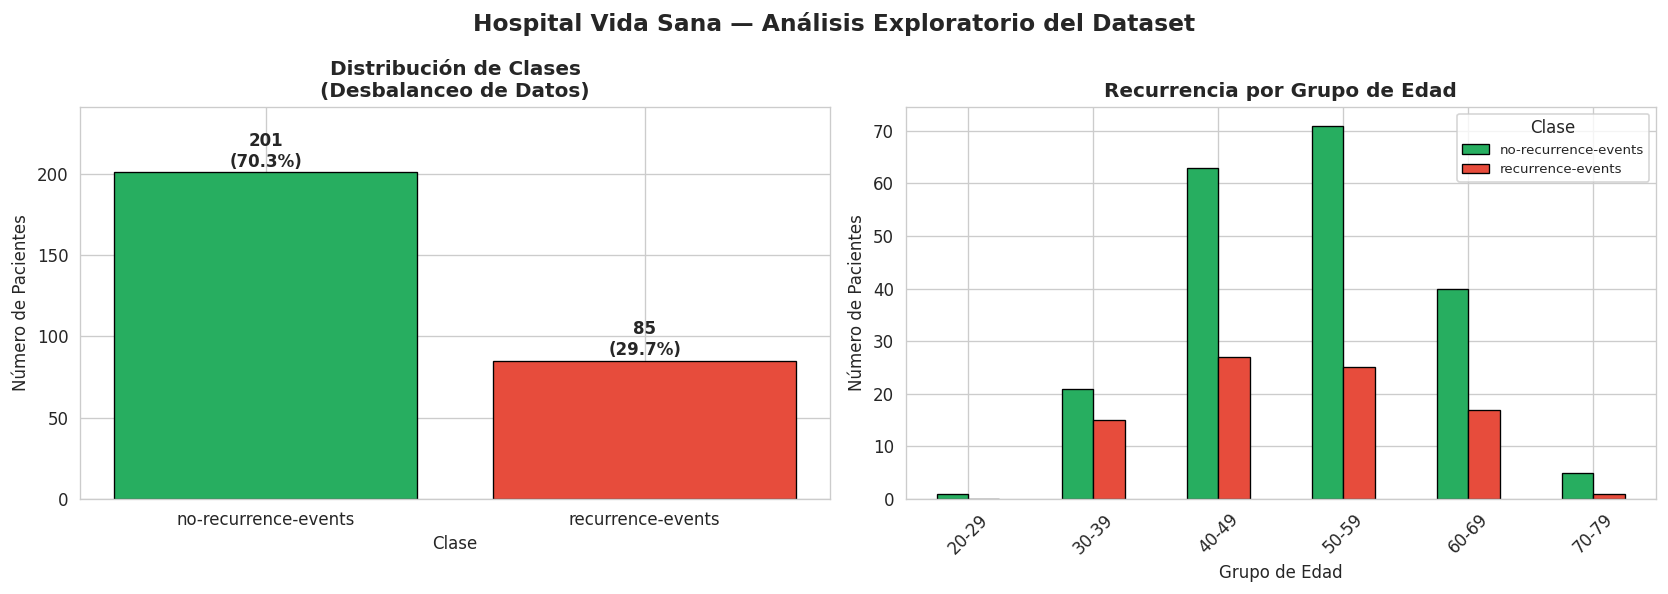

In [ ]:
# ── Visualización del desbalanceo y distribución por edad ────────────────────
COLORS = ['#27ae60', '#e74c3c']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Hospital Vida Sana — Análisis Exploratorio del Dataset', fontsize=14, fontweight='bold')

# Gráfico 1: Distribución de clases
class_counts_sorted = df['target'].value_counts()
bars = axes[0].bar(class_counts_sorted.index, class_counts_sorted.values, color=COLORS, edgecolor='black', linewidth=0.8)
axes[0].set_title('Distribución de Clases\n(Desbalanceo de Datos)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Clase')
axes[0].set_ylabel('Número de Pacientes')
for bar, v in zip(bars, class_counts_sorted.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 1,
                f'{v}\n({v/len(df)*100:.1f}%)', ha='center', va='bottom', fontweight='bold', fontsize=10)
axes[0].set_ylim(0, class_counts_sorted.max() * 1.2)

# Gráfico 2: Recurrencia por grupo de edad
age_order = ['10-19','20-29','30-39','40-49','50-59','60-69','70-79','80-89','90-99']
age_order = [a for a in age_order if a in df['age'].values]
age_ct = pd.crosstab(df['age'], df['target'])
if 'no-recurrence-events' in age_ct.columns:
    col_order = ['no-recurrence-events', 'recurrence-events']
    col_order = [c for c in col_order if c in age_ct.columns]
    age_ct = age_ct[col_order]
age_ct_reindexed = age_ct.reindex([a for a in age_order if a in age_ct.index])
age_ct_reindexed.plot(kind='bar', ax=axes[1], color=COLORS, edgecolor='black', linewidth=0.8, rot=45)
axes[1].set_title('Recurrencia por Grupo de Edad', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Grupo de Edad')
axes[1].set_ylabel('Número de Pacientes')
axes[1].legend(title='Clase', fontsize=8)

plt.tight_layout()
plt.savefig('eda_clases_edad.png', dpi=150, bbox_inches='tight')
plt.show()

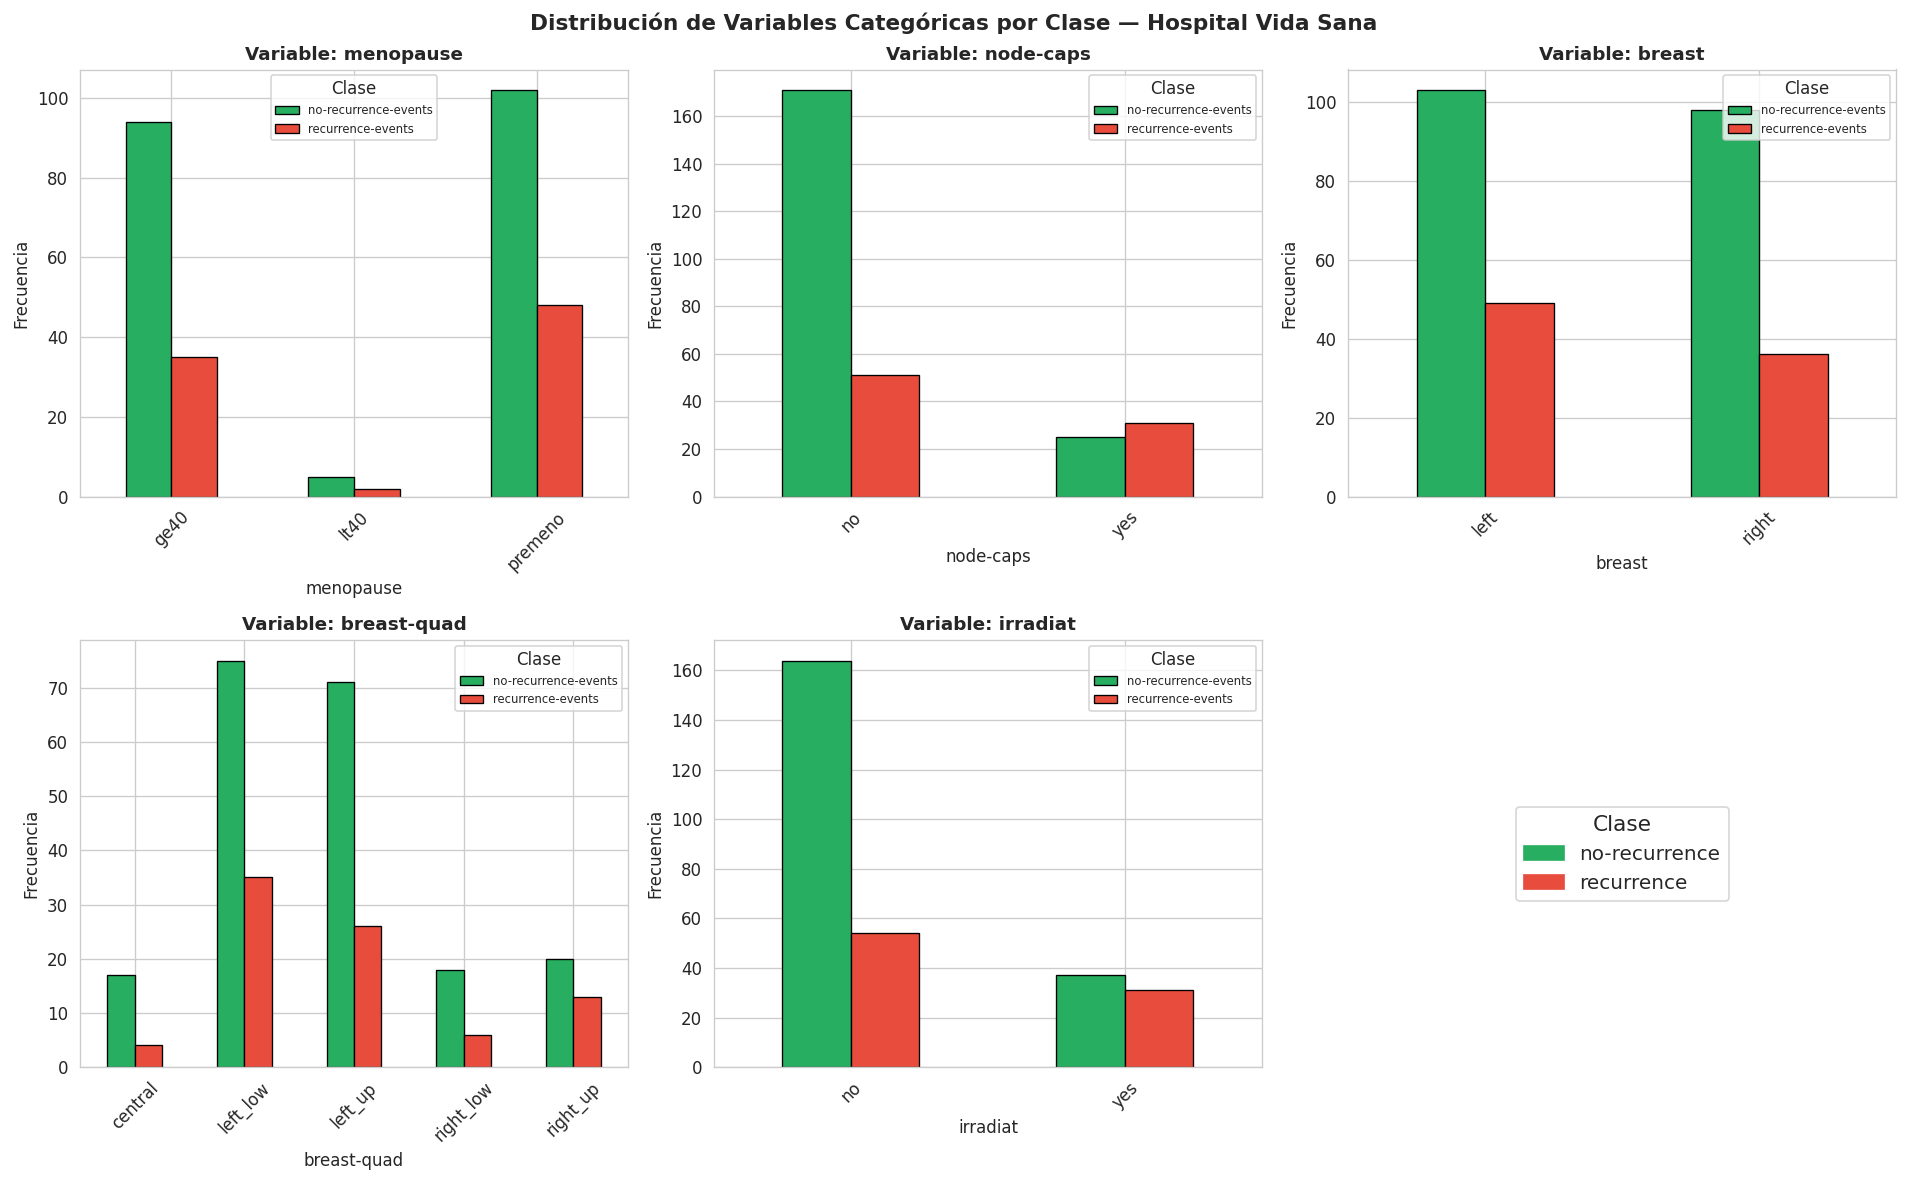

In [ ]:
# ── Distribución de variables categóricas por clase ──────────────────────────
cat_vars = ['menopause', 'node-caps', 'breast', 'breast-quad', 'irradiat']
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Distribución de Variables Categóricas por Clase — Hospital Vida Sana',
             fontsize=13, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(cat_vars):
    ct = pd.crosstab(df[col], df['target'])
    ct.plot(kind='bar', ax=axes[i], color=COLORS, edgecolor='black', linewidth=0.8, rot=45)
    axes[i].set_title(f'Variable: {col}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frecuencia')
    axes[i].legend(title='Clase', fontsize=7)

axes[5].axis('off')
patches = [mpatches.Patch(color=COLORS[0], label='no-recurrence'), mpatches.Patch(color=COLORS[1], label='recurrence')]
axes[5].legend(handles=patches, loc='center', fontsize=12, title='Clase', title_fontsize=13)

plt.tight_layout()
plt.savefig('eda_categoricas.png', dpi=150, bbox_inches='tight')
plt.show()

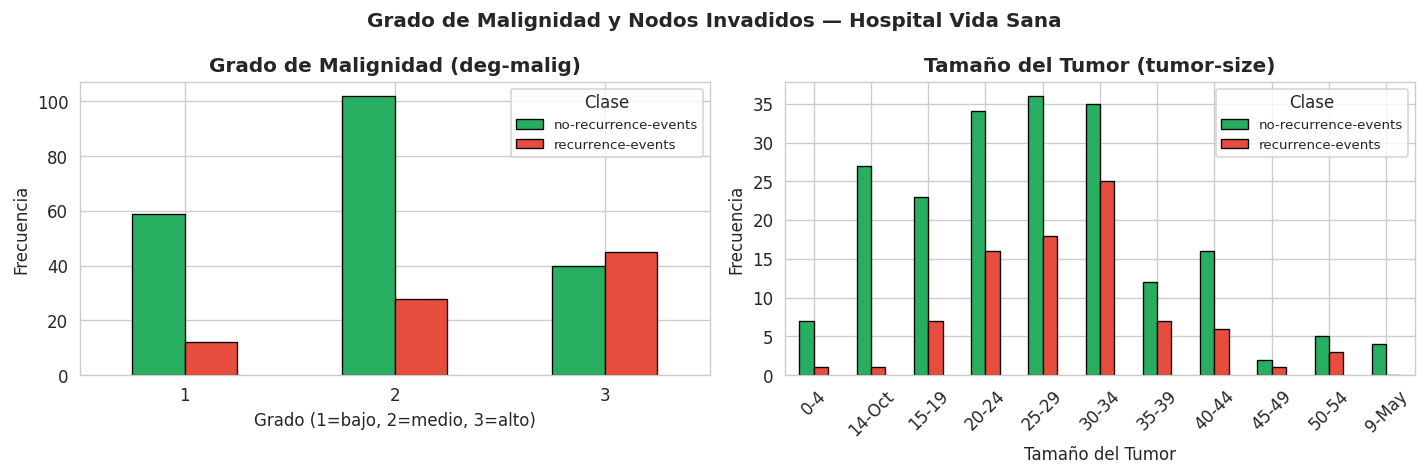


📋 RESUMEN EDA:
  • Total pacientes: 286
  • Variables predictoras: 9
  • Tipo de variables: todas categóricas/ordinales (requieren OHE)
  • Desbalanceo: {'no-recurrence-events': 201, 'recurrence-events': 85}
  • Acción requerida: One-Hot Encoding + SMOTE


In [ ]:
# ── Distribución del grado de malignidad ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Grado de Malignidad y Nodos Invadidos — Hospital Vida Sana', fontweight='bold')

# deg-malig
dm_ct = pd.crosstab(df['deg-malig'], df['target'])
dm_ct.plot(kind='bar', ax=axes[0], color=COLORS, edgecolor='black', linewidth=0.8, rot=0)
axes[0].set_title('Grado de Malignidad (deg-malig)', fontweight='bold')
axes[0].set_xlabel('Grado (1=bajo, 2=medio, 3=alto)')
axes[0].set_ylabel('Frecuencia')
axes[0].legend(title='Clase', fontsize=8)

# tumor-size (top 8)
ts_ct = pd.crosstab(df['tumor-size'], df['target'])
ts_ct.plot(kind='bar', ax=axes[1], color=COLORS, edgecolor='black', linewidth=0.8, rot=45)
axes[1].set_title('Tamaño del Tumor (tumor-size)', fontweight='bold')
axes[1].set_xlabel('Tamaño del Tumor')
axes[1].set_ylabel('Frecuencia')
axes[1].legend(title='Clase', fontsize=8)

plt.tight_layout()
plt.show()

print('\n📋 RESUMEN EDA:')
print(f'  • Total pacientes: {len(df)}')
print(f'  • Variables predictoras: {len(feature_cols)}')
print(f'  • Tipo de variables: todas categóricas/ordinales (requieren OHE)')
print(f'  • Desbalanceo: {df.target.value_counts().to_dict()}')
print(f'  • Acción requerida: One-Hot Encoding + SMOTE')

#### 🔹 Paso 4 — Preprocesamiento: Manejo de Nulos y One-Hot Encoding

In [ ]:
from sklearn.preprocessing import LabelEncoder

print('=' * 65)
print('                    PREPROCESAMIENTO DE DATOS')
print('=' * 65)

df_proc = df.copy()

# ── 1. Reemplazar '?' con la moda de cada columna ────────────────────────────
print('\n1️⃣  Manejo de valores "?" (reemplazo por moda):')
replaced = False
for col in df_proc.columns:
    n_miss = (df_proc[col] == '?').sum()
    if n_miss > 0:
        moda = df_proc[df_proc[col] != '?'][col].mode()[0]
        df_proc[col] = df_proc[col].replace('?', moda)
        print(f'   • {col}: {n_miss} valores reemplazados → moda = "{moda}"')
        replaced = True
if not replaced:
    print('   No se encontraron valores "?"')

# ── 2. Separar X e y ─────────────────────────────────────────────────────────
print('\n2️⃣  Codificación del target (LabelEncoder):')
le = LabelEncoder()
y = le.fit_transform(df_proc['target'])
print(f'   Clases detectadas: {list(le.classes_)}')
print(f'   Codificación: 0 = "{le.classes_[0]}", 1 = "{le.classes_[1]}"')

X_temp = df_proc.drop('target', axis=1).copy()

# ── 3. One-Hot Encoding ───────────────────────────────────────────────────────
print('\n3️⃣  One-Hot Encoding (drop_first=True — variable de referencia):')

# deg-malig es ordinal numérica: 1, 2, 3 → se mantiene como int
X_temp['deg-malig'] = X_temp['deg-malig'].astype(int)

# Variables nominales a codificar
ohe_cols = ['age','menopause','tumor-size','inv-nodes','node-caps','breast','breast-quad','irradiat']

X_enc = pd.get_dummies(X_temp, columns=ohe_cols, drop_first=True)
X_enc = X_enc.astype(int)

print(f'   Variables originales: {X_temp.shape[1]}')
print(f'   Variables tras OHE:   {X_enc.shape[1]}')

print('\n   📌 Categorías de referencia (eliminadas con drop_first=True):')
ref_cats = {
    'age': '10-19', 'menopause': 'ge40', 'tumor-size': '0-4',
    'inv-nodes': '0-2', 'node-caps': 'no', 'breast': 'left',
    'breast-quad': 'central', 'irradiat': 'no'
}
for var, ref in ref_cats.items():
    print(f'   • {var}: referencia = "{ref}"')

print(f'\n   Columnas resultantes ({X_enc.shape[1]} variables):')
print(f'   {list(X_enc.columns)}')

X_enc.head(5)

                    PREPROCESAMIENTO DE DATOS

1️⃣  Manejo de valores "?" (reemplazo por moda):
   No se encontraron valores "?"

2️⃣  Codificación del target (LabelEncoder):
   Clases detectadas: ['no-recurrence-events', 'recurrence-events']
   Codificación: 0 = "no-recurrence-events", 1 = "recurrence-events"

3️⃣  One-Hot Encoding (drop_first=True — variable de referencia):
   Variables originales: 9
   Variables tras OHE:   31

   📌 Categorías de referencia (eliminadas con drop_first=True):
   • age: referencia = "10-19"
   • menopause: referencia = "ge40"
   • tumor-size: referencia = "0-4"
   • inv-nodes: referencia = "0-2"
   • node-caps: referencia = "no"
   • breast: referencia = "left"
   • breast-quad: referencia = "central"
   • irradiat: referencia = "no"

   Columnas resultantes (31 variables):
   ['deg-malig', 'age_30-39', 'age_40-49', 'age_50-59', 'age_60-69', 'age_70-79', 'menopause_lt40', 'menopause_premeno', 'tumor-size_14-Oct', 'tumor-size_15-19', 'tumor-size_20-24',

,deg-malig,age_30-39,age_40-49,age_50-59,age_60-69,age_70-79,menopause_lt40,menopause_premeno,tumor-size_14-Oct,tumor-size_15-19,...,inv-nodes_24-26,inv-nodes_5-Mar,inv-nodes_8-Jun,node-caps_yes,breast_right,breast-quad_left_low,breast-quad_left_up,breast-quad_right_low,breast-quad_right_up,irradiat_yes
0,3,1,0,0,0,0,0,1,0,0,...,0,0,0,0,0,1,0,0,0,0
1,2,0,1,0,0,0,0,1,0,0,...,0,0,0,0,1,0,0,0,1,0
2,2,0,1,0,0,0,0,1,0,0,...,0,0,0,0,0,1,0,0,0,0
3,2,0,0,0,1,0,0,0,0,1,...,0,0,0,0,1,0,1,0,0,0
4,2,0,1,0,0,0,0,1,0,0,...,0,0,0,0,1,0,0,1,0,0


#### 🔹 Paso 5 — División Train / Test (Estratificada)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_enc, y, test_size=0.2, random_state=42, stratify=y
)

print('=' * 65)
print('               DIVISIÓN TRAIN / TEST ESTRATIFICADA')
print('=' * 65)
print(f'  • Total muestras:  {len(X_enc)}')
print(f'  • Train (80%):     {len(X_train)} muestras')
print(f'  • Test  (20%):     {len(X_test)} muestras')
print(f'\n  Distribución en TRAIN:')
for cls_idx, cls_name in enumerate(le.classes_):
    cnt = (y_train == cls_idx).sum()
    print(f'    Clase {cls_idx} ({cls_name}): {cnt} ({cnt/len(y_train)*100:.1f}%)')
print(f'  Distribución en TEST:')
for cls_idx, cls_name in enumerate(le.classes_):
    cnt = (y_test == cls_idx).sum()
    print(f'    Clase {cls_idx} ({cls_name}): {cnt} ({cnt/len(y_test)*100:.1f}%)')
print(f'\n  ✅ stratify=y asegura proporciones similares en train y test')

               DIVISIÓN TRAIN / TEST ESTRATIFICADA
  • Total muestras:  286
  • Train (80%):     228 muestras
  • Test  (20%):     58 muestras

  Distribución en TRAIN:
    Clase 0 (no-recurrence-events): 160 (70.2%)
    Clase 1 (recurrence-events): 68 (29.8%)
  Distribución en TEST:
    Clase 0 (no-recurrence-events): 41 (70.7%)
    Clase 1 (recurrence-events): 17 (29.3%)

  ✅ stratify=y asegura proporciones similares en train y test


#### 🔹 Paso 6 — Manejo de Desbalanceo: SMOTE

          MANEJO DE DESBALANCEO — SMOTE
  ⚠️  SMOTE se aplica SOLO sobre X_train (NO sobre X_test)
      Esto evita data leakage y mantiene la evaluación honesta.

  ANTES de SMOTE (Train):
    Clase 0 (no-recurrence-events): 160 muestras
    Clase 1 (recurrence-events): 68 muestras
    Ratio: 2.35:1

  DESPUÉS de SMOTE (Train):
    Clase 0 (no-recurrence-events): 160 muestras
    Clase 1 (recurrence-events): 160 muestras
    Ratio: 1.00:1 → Balance perfecto

  Muestras sintéticas generadas: 92


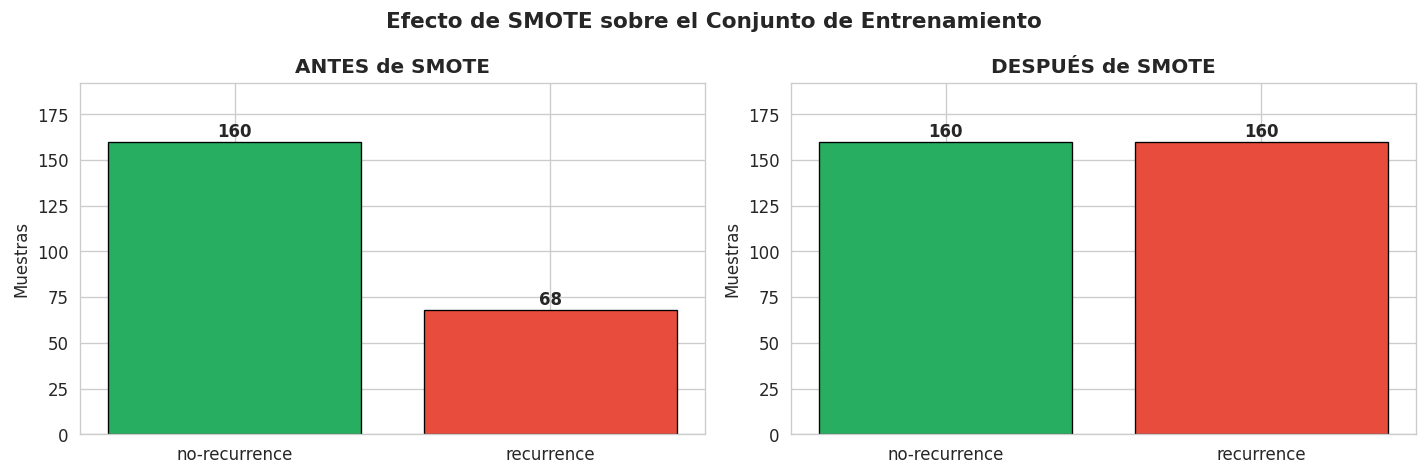

In [ ]:
from imblearn.over_sampling import SMOTE

print('=' * 65)
print('          MANEJO DE DESBALANCEO — SMOTE')
print('=' * 65)
print('  ⚠️  SMOTE se aplica SOLO sobre X_train (NO sobre X_test)')
print('      Esto evita data leakage y mantiene la evaluación honesta.\n')

before_counts = np.bincount(y_train)
print(f'  ANTES de SMOTE (Train):')
for i, c in enumerate(le.classes_):
    print(f'    Clase {i} ({c}): {before_counts[i]} muestras')
print(f'    Ratio: {before_counts.max()/before_counts.min():.2f}:1')

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

after_counts = np.bincount(y_train_sm)
print(f'\n  DESPUÉS de SMOTE (Train):')
for i, c in enumerate(le.classes_):
    print(f'    Clase {i} ({c}): {after_counts[i]} muestras')
print(f'    Ratio: {after_counts.max()/after_counts.min():.2f}:1 → Balance perfecto')
print(f'\n  Muestras sintéticas generadas: {X_train_sm.shape[0] - X_train.shape[0]}')

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Efecto de SMOTE sobre el Conjunto de Entrenamiento', fontsize=13, fontweight='bold')
labels_plot = [c.replace('no-recurrence-events','no-recurrence') for c in le.classes_]
labels_plot = [l.replace('recurrence-events','recurrence') for l in labels_plot]

for ax, counts, title in zip(axes, [before_counts, after_counts],
                              ['ANTES de SMOTE', 'DESPUÉS de SMOTE']):
    bars = ax.bar(labels_plot, counts, color=COLORS, edgecolor='black', linewidth=0.8)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('Muestras')
    for bar, v in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.5, str(v),
                ha='center', va='bottom', fontweight='bold')
    ax.set_ylim(0, max(counts) * 1.2)

plt.tight_layout()
plt.savefig('smote_balance.png', dpi=150, bbox_inches='tight')
plt.show()

#### 🔹 Paso 6b — Escalado de Características (StandardScaler)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_sm)   # fit + transform en train (con SMOTE)
X_test_sc  = scaler.transform(X_test)            # solo transform en test

print('✅ StandardScaler aplicado:')
print(f'  • fit() realizado sobre X_train_sm: {X_train_sc.shape}')
print(f'  • transform() aplicado a X_test:    {X_test_sc.shape}')
print(f'  ⚠️  El scaler se ajusta SOLO en train → evita data leakage')
print(f'\n  Medias (train, primeras 5 features): {X_train_sc[:, :5].mean(axis=0).round(4)}')
print(f'  Std   (train, primeras 5 features): {X_train_sc[:, :5].std(axis=0).round(4)}')

✅ StandardScaler aplicado:
  • fit() realizado sobre X_train_sm: (320, 31)
  • transform() aplicado a X_test:    (58, 31)
  ⚠️  El scaler se ajusta SOLO en train → evita data leakage

  Medias (train, primeras 5 features): [-0. -0. -0. -0. -0.]
  Std   (train, primeras 5 features): [1. 1. 1. 1. 1.]


#### 🔹 Funciones Auxiliares de Evaluación

In [ ]:
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve,
    ConfusionMatrixDisplay, f1_score, accuracy_score, precision_score, recall_score
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Diccionarios para almacenar resultados comparativos
RESULTADOS = {}
ROC_DATA   = {}

CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
CLS_NAMES = ['no-rec.', 'recurrence']

def evaluar_modelo(nombre, gs, X_te=X_test_sc, y_te=y_test, guardar=True):
    """Imprime métricas completas del mejor modelo del GridSearchCV."""
    best = gs.best_estimator_
    y_pred = best.predict(X_te)
    # Probabilidades (SVC necesita probability=True o usamos decision_function)
    if hasattr(best, 'predict_proba'):
        y_prob = best.predict_proba(X_te)[:, 1]
    else:
        y_prob = best.decision_function(X_te)
        y_prob = (y_prob - y_prob.min()) / (y_prob.max() - y_prob.min())

    acc  = accuracy_score(y_te, y_pred)
    f1m  = f1_score(y_te, y_pred, average='macro')
    prec = precision_score(y_te, y_pred, average='macro')
    rec  = recall_score(y_te, y_pred, average='macro')
    auc  = roc_auc_score(y_te, y_prob)

    print(f'\n{"="*65}')
    print(f'  MODELO: {nombre}')
    print(f'{"="*65}')
    print(f'  Mejores hiperparámetros: {gs.best_params_}')
    print(f'  Mejor score CV (F1-macro): {gs.best_score_:.4f}')
    print(f'\n  ─── Métricas en conjunto de TEST ───')
    print(f'  Accuracy:    {acc:.4f}')
    print(f'  F1-macro:    {f1m:.4f}')
    print(f'  Precision:   {prec:.4f}')
    print(f'  Recall:      {rec:.4f}')
    print(f'  AUC-ROC:     {auc:.4f}')
    print(f'\n  Reporte completo:')
    print(classification_report(y_te, y_pred, target_names=CLS_NAMES))

    # Matriz de confusión
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay.from_predictions(
        y_te, y_pred, display_labels=CLS_NAMES, cmap='Blues', ax=ax)
    ax.set_title(f'Matriz de Confusión\n{nombre}', fontweight='bold', fontsize=11)
    plt.tight_layout()
    plt.show()

    if guardar:
        RESULTADOS[nombre] = {'Accuracy': acc, 'F1-macro': f1m,
                               'Precision': prec, 'Recall': rec, 'AUC-ROC': auc}
        ROC_DATA[nombre] = (y_prob, auc)

    return y_prob, auc

print('✅ Funciones auxiliares definidas. Listo para entrenar modelos.')

✅ Funciones auxiliares definidas. Listo para entrenar modelos.


---
#### 🌳 Paso 7 — Modelo 1: Árbol de Decisión con GridSearchCV

Entrenando Árbol de Decisión con GridSearchCV...
(Esto puede tardar unos segundos)


  MODELO: Árbol de Decisión
  Mejores hiperparámetros: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
  Mejor score CV (F1-macro): 0.7427

  ─── Métricas en conjunto de TEST ───
  Accuracy:    0.6034
  F1-macro:    0.5436
  Precision:   0.5434
  Recall:      0.5473
  AUC-ROC:     0.5452

  Reporte completo:
              precision    recall  f1-score   support

     no-rec.       0.74      0.68      0.71        41
  recurrence       0.35      0.41      0.38        17

    accuracy                           0.60        58
   macro avg       0.54      0.55      0.54        58
weighted avg       0.62      0.60      0.61        58



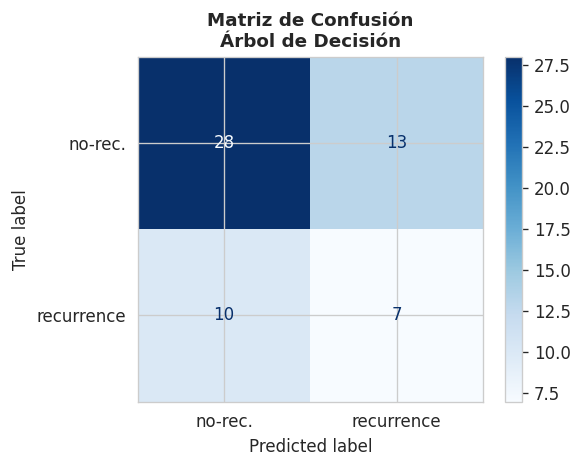

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

print('Entrenando Árbol de Decisión con GridSearchCV...')
print('(Esto puede tardar unos segundos)\n')

param_dt = {
    'criterion':         ['gini', 'entropy'],
    'max_depth':         [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4]
}

gs_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_dt, cv=CV, scoring='f1_macro', n_jobs=-1, refit=True, verbose=0
)
gs_dt.fit(X_train_sc, y_train_sm)

y_prob_dt, auc_dt = evaluar_modelo('Árbol de Decisión', gs_dt)

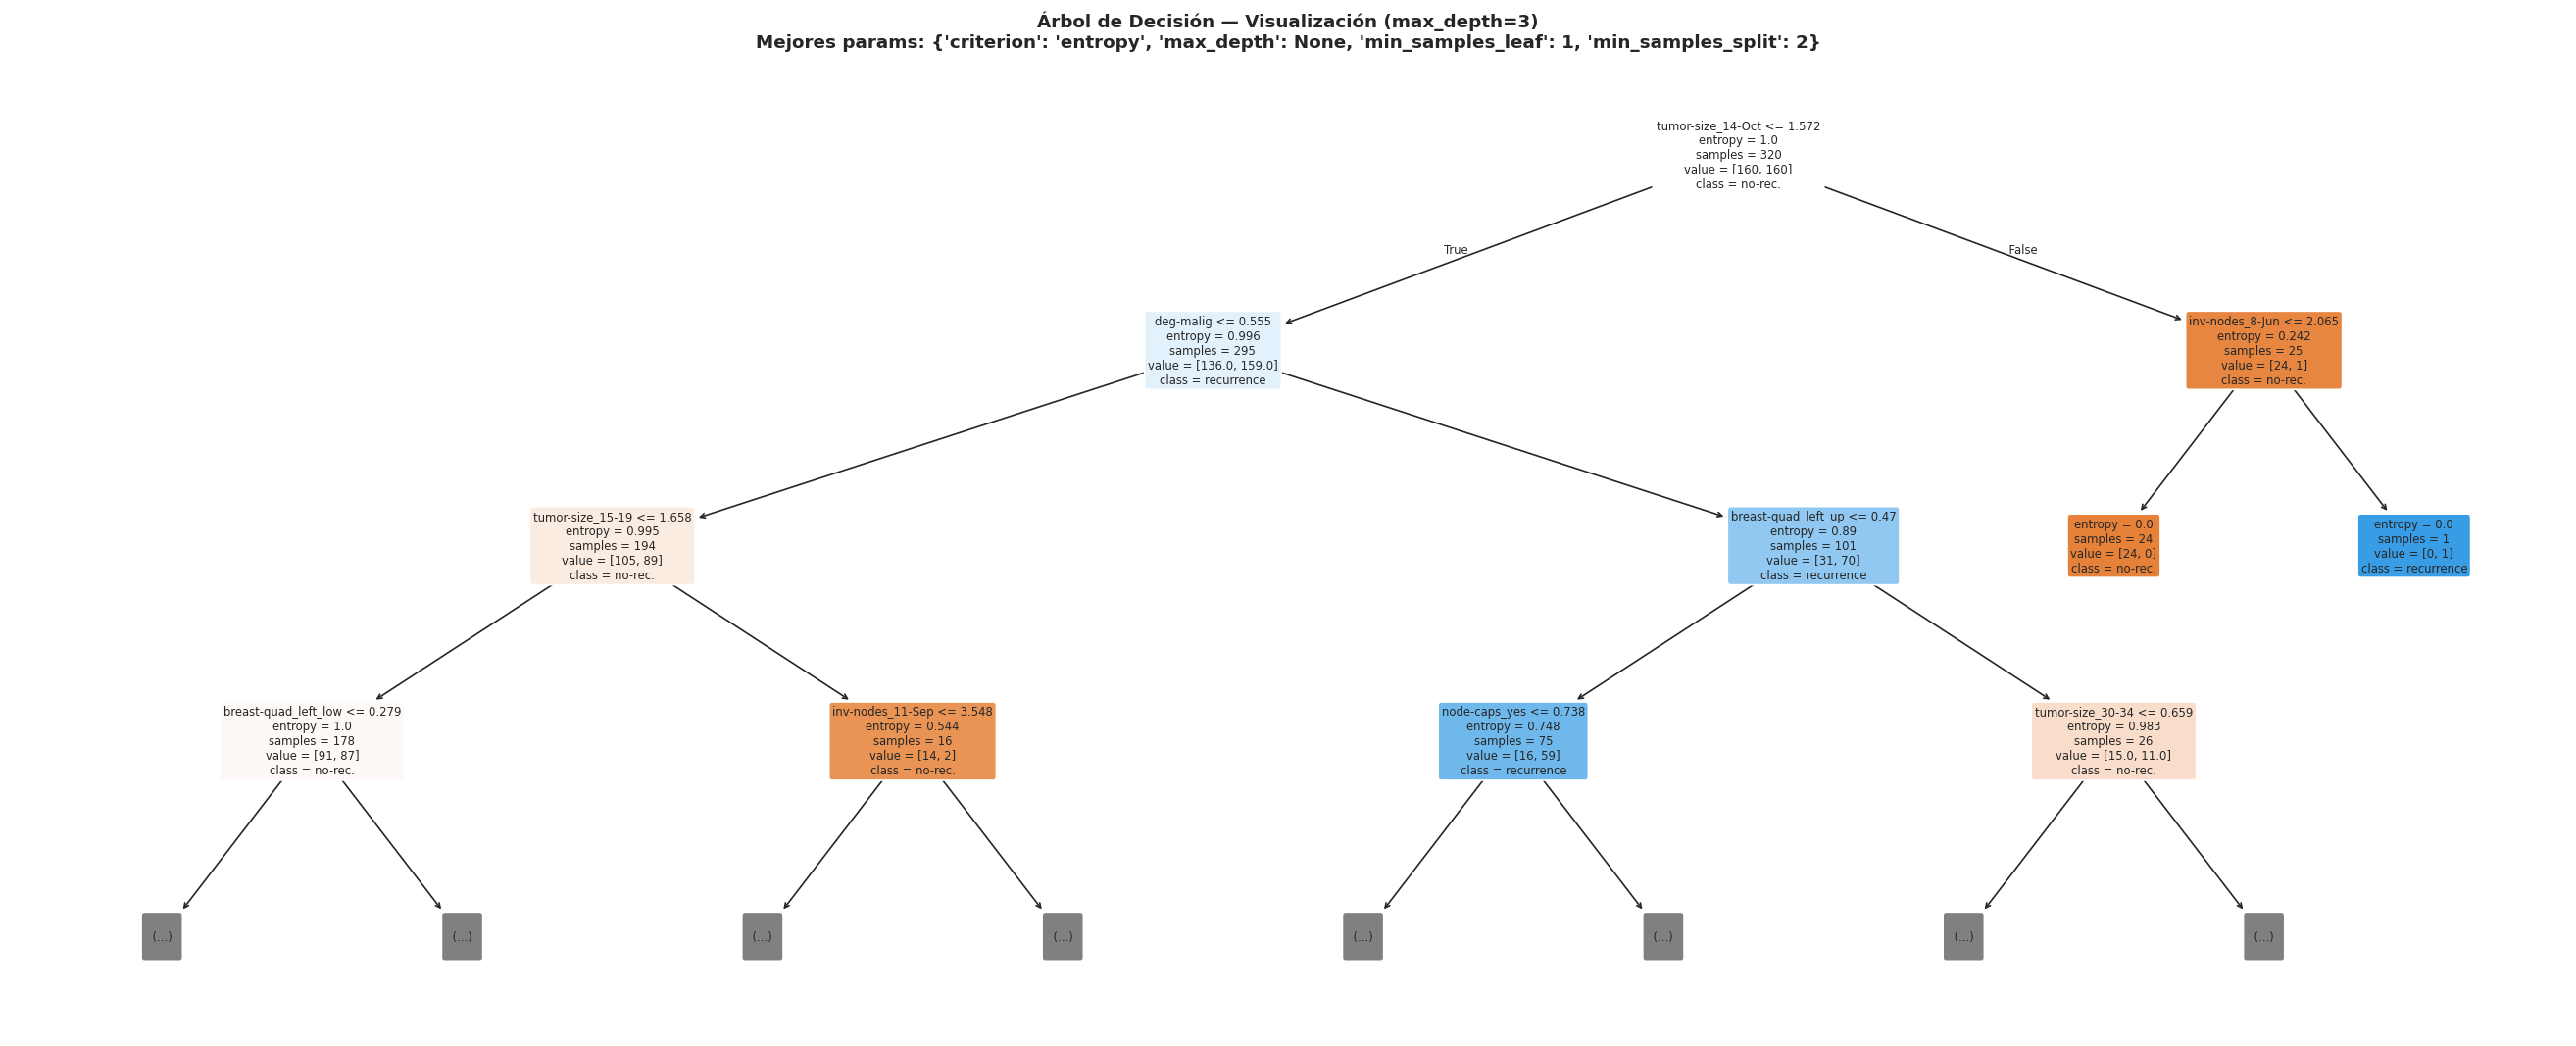

In [ ]:
# Visualización del árbol (profundidad máxima 3 para legibilidad)
fig, ax = plt.subplots(figsize=(22, 9))
plot_tree(
    gs_dt.best_estimator_,
    feature_names=list(X_enc.columns),
    class_names=CLS_NAMES,
    filled=True, rounded=True, max_depth=3, ax=ax, fontsize=7
)
ax.set_title(
    f'Árbol de Decisión — Visualización (max_depth=3)\n'
    f'Mejores params: {gs_dt.best_params_}',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.savefig('arbol_decision.png', dpi=120, bbox_inches='tight')
plt.show()

---
#### 🌲 Paso 8 — Modelo 2: Random Forest con GridSearchCV

Entrenando Random Forest con GridSearchCV...
(Puede tardar 1-2 minutos)


  MODELO: Random Forest
  Mejores hiperparámetros: {'max_depth': 10, 'max_features': 'log2', 'min_samples_split': 2, 'n_estimators': 50}
  Mejor score CV (F1-macro): 0.7893

  ─── Métricas en conjunto de TEST ───
  Accuracy:    0.6897
  F1-macro:    0.6478
  Precision:   0.6435
  Recall:      0.6600
  AUC-ROC:     0.6399

  Reporte completo:
              precision    recall  f1-score   support

     no-rec.       0.81      0.73      0.77        41
  recurrence       0.48      0.59      0.53        17

    accuracy                           0.69        58
   macro avg       0.64      0.66      0.65        58
weighted avg       0.71      0.69      0.70        58



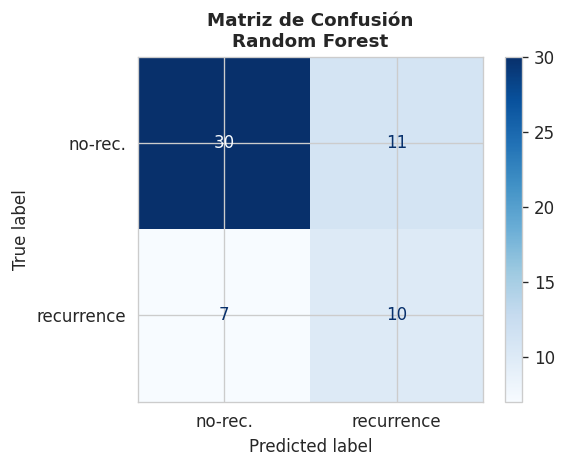

In [ ]:
from sklearn.ensemble import RandomForestClassifier

print('Entrenando Random Forest con GridSearchCV...')
print('(Puede tardar 1-2 minutos)\n')

param_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth':    [5, 10, 20, None],
    'max_features': ['sqrt', 'log2'],
    'min_samples_split': [2, 5]
}

gs_rf = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_rf, cv=CV, scoring='f1_macro', n_jobs=-1, refit=True, verbose=0
)
gs_rf.fit(X_train_sc, y_train_sm)

y_prob_rf, auc_rf = evaluar_modelo('Random Forest', gs_rf)

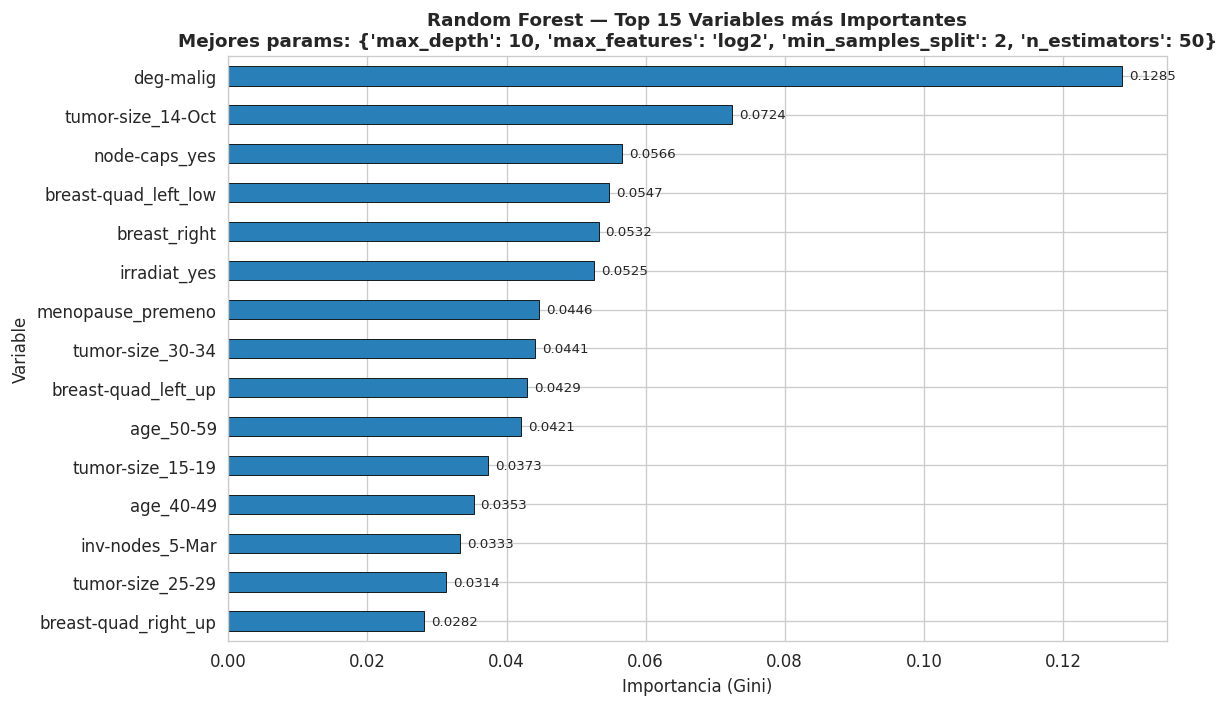


📌 Las 5 variables más importantes para predecir recurrencia:
  1. deg-malig: 0.1285
  2. tumor-size_14-Oct: 0.0724
  3. node-caps_yes: 0.0566
  4. breast-quad_left_low: 0.0547
  5. breast_right: 0.0532


In [ ]:
# Feature Importance
importances = gs_rf.best_estimator_.feature_importances_
feat_imp = pd.Series(importances, index=X_enc.columns).sort_values(ascending=False)

top_n = 15
fig, ax = plt.subplots(figsize=(10, 6))
feat_imp.head(top_n).plot(kind='barh', ax=ax, color='#2980b9', edgecolor='black', linewidth=0.5)
ax.invert_yaxis()
ax.set_title(f'Random Forest — Top {top_n} Variables más Importantes\n'
             f'Mejores params: {gs_rf.best_params_}', fontsize=11, fontweight='bold')
ax.set_xlabel('Importancia (Gini)')
ax.set_ylabel('Variable')
for i, (val, name) in enumerate(zip(feat_imp.head(top_n), feat_imp.head(top_n).index)):
    ax.text(val + 0.001, i, f'{val:.4f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig('rf_feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'\n📌 Las 5 variables más importantes para predecir recurrencia:')
for i, (name, imp) in enumerate(feat_imp.head(5).items(), 1):
    print(f'  {i}. {name}: {imp:.4f}')

---
#### 🔵 Paso 9 — Modelo 3: k-NN con GridSearchCV

Entrenando k-NN con GridSearchCV...

  MODELO: k-NN
  Mejores hiperparámetros: {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'distance'}
  Mejor score CV (F1-macro): 0.7418

  ─── Métricas en conjunto de TEST ───
  Accuracy:    0.7069
  F1-macro:    0.6522
  Precision:   0.6500
  Recall:      0.6549
  AUC-ROC:     0.6908

  Reporte completo:
              precision    recall  f1-score   support

     no-rec.       0.80      0.78      0.79        41
  recurrence       0.50      0.53      0.51        17

    accuracy                           0.71        58
   macro avg       0.65      0.65      0.65        58
weighted avg       0.71      0.71      0.71        58



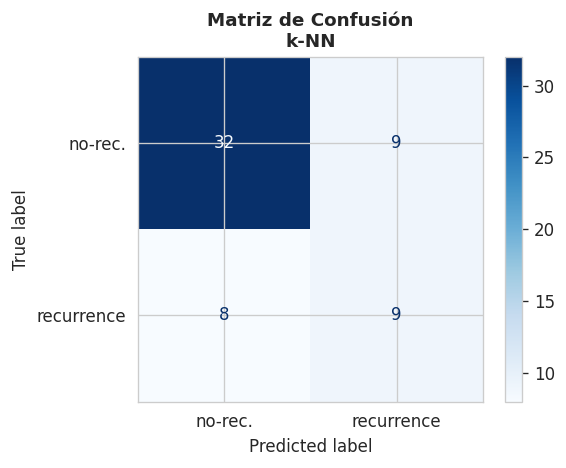

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

print('Entrenando k-NN con GridSearchCV...')

param_knn = {
    'n_neighbors': [3, 5, 7, 9, 11, 15, 21],
    'weights':     ['uniform', 'distance'],
    'metric':      ['euclidean', 'manhattan']
}

gs_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_knn, cv=CV, scoring='f1_macro', n_jobs=-1, refit=True, verbose=0
)
gs_knn.fit(X_train_sc, y_train_sm)

y_prob_knn, auc_knn = evaluar_modelo('k-NN', gs_knn)

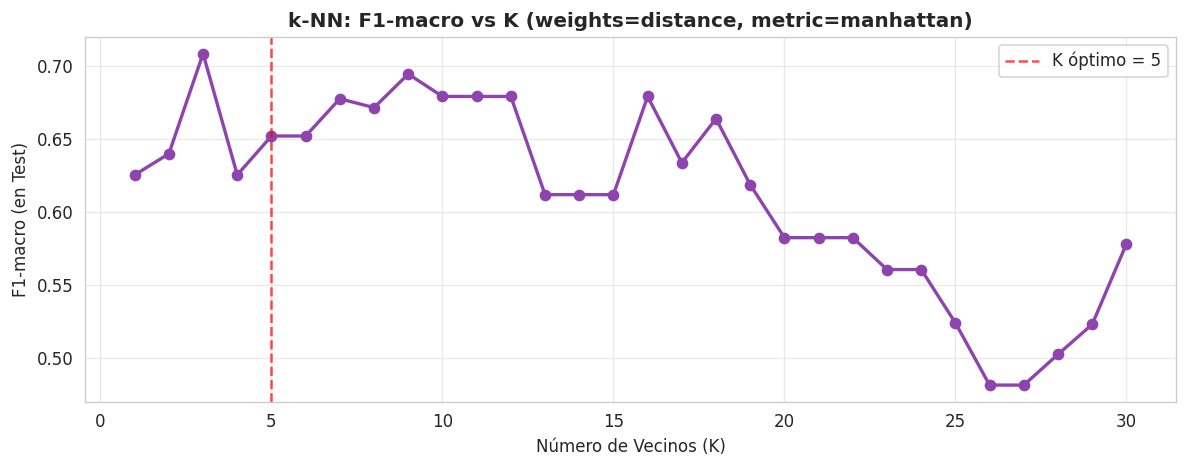

  K óptimo encontrado: 5 (weights=distance, metric=manhattan)


In [ ]:
# Curva F1-macro vs K (para weight y metric óptimos del GridSearch)
best_w = gs_knn.best_params_['weights']
best_m = gs_knn.best_params_['metric']

k_range = range(1, 31)
f1_scores = []
for k in k_range:
    knn_tmp = KNeighborsClassifier(n_neighbors=k, weights=best_w, metric=best_m)
    knn_tmp.fit(X_train_sc, y_train_sm)
    f1_scores.append(f1_score(y_test, knn_tmp.predict(X_test_sc), average='macro'))

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(k_range, f1_scores, marker='o', color='#8e44ad', linewidth=2, markersize=6)
best_k = gs_knn.best_params_['n_neighbors']
ax.axvline(x=best_k, color='red', linestyle='--', alpha=0.7, label=f'K óptimo = {best_k}')
ax.set_title(f'k-NN: F1-macro vs K (weights={best_w}, metric={best_m})',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Número de Vecinos (K)')
ax.set_ylabel('F1-macro (en Test)')
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('knn_k_curve.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'  K óptimo encontrado: {best_k} (weights={best_w}, metric={best_m})')

---
#### 📈 Paso 10 — Modelo 4: Regresión Logística + Interpretación (Odds Ratios)

Entrenando Regresión Logística con GridSearchCV...

  MODELO: Regresión Logística
  Mejores hiperparámetros: {'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}
  Mejor score CV (F1-macro): 0.7262

  ─── Métricas en conjunto de TEST ───
  Accuracy:    0.6207
  F1-macro:    0.5695
  Precision:   0.5689
  Recall:      0.5768
  AUC-ROC:     0.6083

  Reporte completo:
              precision    recall  f1-score   support

     no-rec.       0.76      0.68      0.72        41
  recurrence       0.38      0.47      0.42        17

    accuracy                           0.62        58
   macro avg       0.57      0.58      0.57        58
weighted avg       0.65      0.62      0.63        58



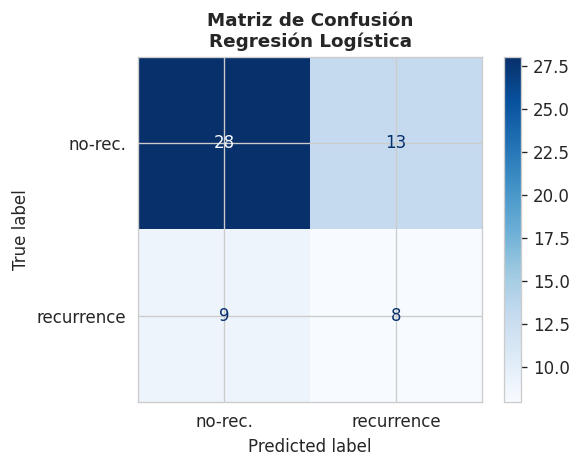

In [ ]:
from sklearn.linear_model import LogisticRegression

print('Entrenando Regresión Logística con GridSearchCV...')

param_lr = {
    'C':       [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'],
    'solver':  ['lbfgs', 'saga']
}

gs_lr = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_lr, cv=CV, scoring='f1_macro', n_jobs=-1, refit=True, verbose=0
)
gs_lr.fit(X_train_sc, y_train_sm)

y_prob_lr, auc_lr = evaluar_modelo('Regresión Logística', gs_lr)

In [ ]:
# ── Interpretación: Odds Ratios ──────────────────────────────────────────────
print('=' * 65)
print('  INTERPRETACIÓN: ODDS RATIOS — Regresión Logística')
print('=' * 65)
print('  Variable objetivo: recurrence-events (clase 1)')
print('  Interpretación: OR > 1 aumenta riesgo de recurrencia')
print('                  OR < 1 reduce  riesgo de recurrencia\n')

best_lr = gs_lr.best_estimator_
coefs = best_lr.coef_[0]
feature_names = list(X_enc.columns)

# Tabla de Odds Ratios
or_df = pd.DataFrame({
    'Variable': feature_names,
    'Coeficiente (β)': coefs,
    'Odds Ratio (eβ)': np.exp(coefs)
}).sort_values('Odds Ratio (eβ)', ascending=False)

or_df['Efecto'] = or_df['Odds Ratio (eβ)'].apply(
    lambda x: '🔺 Aumenta riesgo' if x > 1 else '🔻 Reduce riesgo'
)

print('  Top 10 variables por Odds Ratio:')
print(or_df[['Variable','Coeficiente (β)','Odds Ratio (eβ)','Efecto']].head(10).to_string(index=False))

# Interpretación de las 3 más influyentes
print('\n  📋 INTERPRETACIÓN CLÍNICA (respecto a categoría de referencia):')
for _, row in or_df.head(3).iterrows():
    or_val = row['Odds Ratio (eβ)']
    pct = abs(or_val - 1) * 100
    direction = 'aumenta' if or_val > 1 else 'reduce'
    print(f'\n  • {row["Variable"]}:')
    print(f'    OR = {or_val:.3f} → {direction} el riesgo de recurrencia en un {pct:.1f}%')
    print(f'    (respecto a la categoría de referencia de esa variable)')

  INTERPRETACIÓN: ODDS RATIOS — Regresión Logística
  Variable objetivo: recurrence-events (clase 1)
  Interpretación: OR > 1 aumenta riesgo de recurrencia
                  OR < 1 reduce  riesgo de recurrencia

  Top 10 variables por Odds Ratio:
            Variable  Coeficiente (β)  Odds Ratio (eβ)           Efecto
           deg-malig         0.472944         1.604711 🔺 Aumenta riesgo
    inv-nodes_11-Sep         0.329320         1.390023 🔺 Aumenta riesgo
        irradiat_yes         0.266074         1.304831 🔺 Aumenta riesgo
       node-caps_yes         0.219269         1.245167 🔺 Aumenta riesgo
     inv-nodes_24-26         0.166767         1.181479 🔺 Aumenta riesgo
      menopause_lt40         0.121850         1.129585 🔺 Aumenta riesgo
breast-quad_right_up         0.059872         1.061701 🔺 Aumenta riesgo
     inv-nodes_15-17         0.053803         1.055277 🔺 Aumenta riesgo
    inv-nodes_14-Dec         0.031515         1.032017 🔺 Aumenta riesgo
     inv-nodes_5-Mar        -0.00

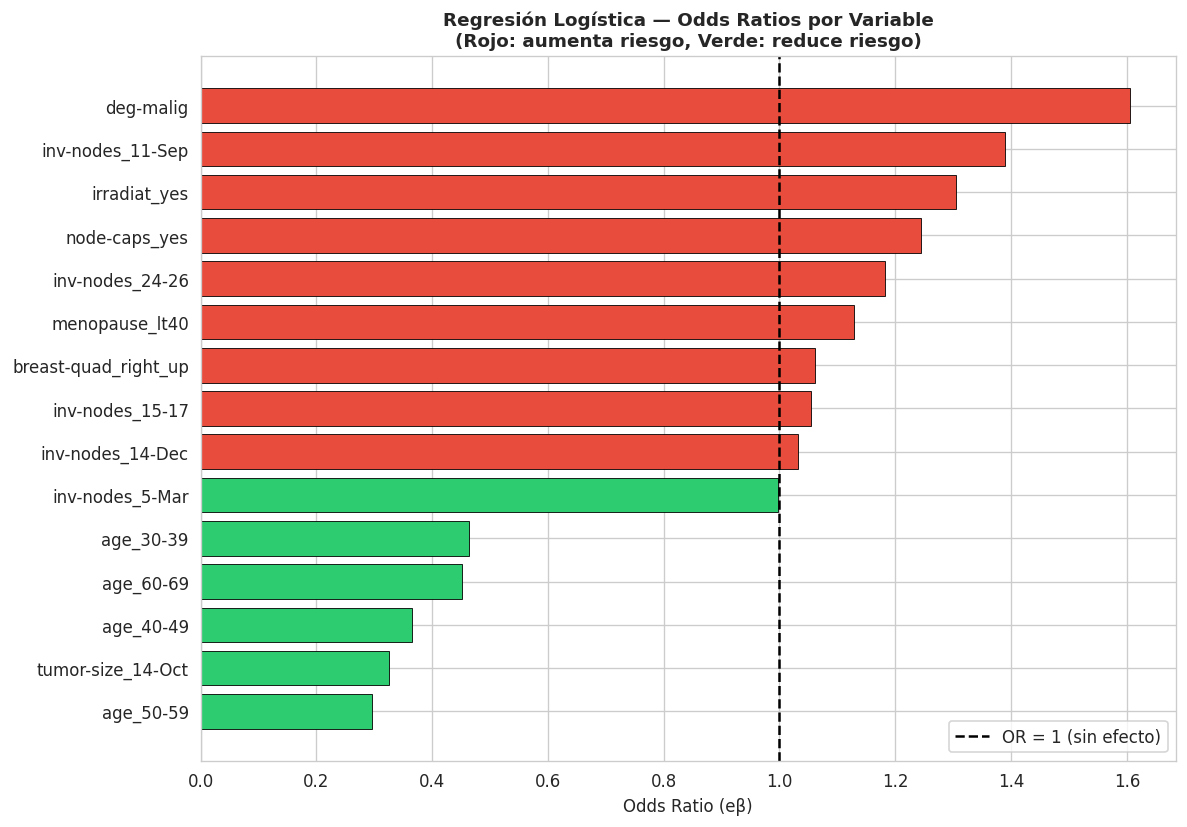

In [ ]:
# Gráfico de Odds Ratios
top_or = or_df.head(10).copy()
bot_or = or_df.tail(5).copy()
plot_or = pd.concat([top_or, bot_or]).drop_duplicates()

fig, ax = plt.subplots(figsize=(10, 7))
colors_or = ['#e74c3c' if x > 1 else '#2ecc71' for x in plot_or['Odds Ratio (eβ)']]
ax.barh(plot_or['Variable'], plot_or['Odds Ratio (eβ)'], color=colors_or, edgecolor='black', linewidth=0.5)
ax.axvline(x=1, color='black', linestyle='--', linewidth=1.5, label='OR = 1 (sin efecto)')
ax.set_title('Regresión Logística — Odds Ratios por Variable\n'
             '(Rojo: aumenta riesgo, Verde: reduce riesgo)', fontsize=11, fontweight='bold')
ax.set_xlabel('Odds Ratio (eβ)')
ax.invert_yaxis()
ax.legend()
plt.tight_layout()
plt.savefig('logistic_odds_ratios.png', dpi=120, bbox_inches='tight')
plt.show()

---
#### ⚡ Paso 11 — Modelo 5: SVM con GridSearchCV

Entrenando SVM con GridSearchCV...
(Puede tardar 2-3 minutos con el grid completo)


  MODELO: SVM
  Mejores hiperparámetros: {'C': 10, 'gamma': 'scale', 'kernel': 'poly'}
  Mejor score CV (F1-macro): 0.7509

  ─── Métricas en conjunto de TEST ───
  Accuracy:    0.6552
  F1-macro:    0.5685
  Precision:   0.5721
  Recall:      0.5667
  AUC-ROC:     0.6442

  Reporte completo:
              precision    recall  f1-score   support

     no-rec.       0.74      0.78      0.76        41
  recurrence       0.40      0.35      0.38        17

    accuracy                           0.66        58
   macro avg       0.57      0.57      0.57        58
weighted avg       0.64      0.66      0.65        58



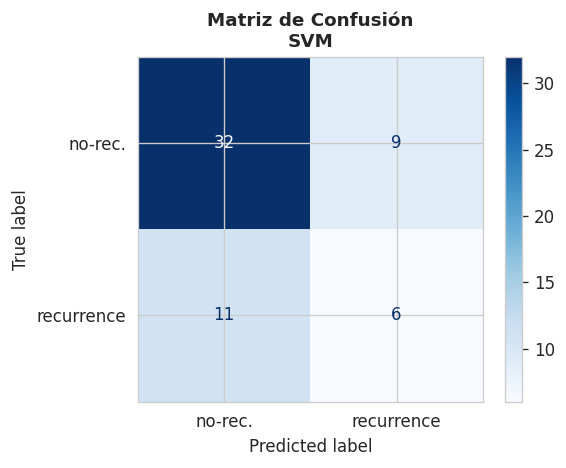

In [ ]:
from sklearn.svm import SVC

print('Entrenando SVM con GridSearchCV...')
print('(Puede tardar 2-3 minutos con el grid completo)\n')

param_svm = {
    'C':      [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma':  ['scale', 'auto']
}

gs_svm = GridSearchCV(
    SVC(probability=True, random_state=42, class_weight='balanced'),
    param_svm, cv=CV, scoring='f1_macro', n_jobs=-1, refit=True, verbose=0
)
gs_svm.fit(X_train_sc, y_train_sm)

y_prob_svm, auc_svm = evaluar_modelo('SVM', gs_svm)

In [ ]:
# Comparación SMOTE vs class_weight='balanced' para SVM
print('=' * 65)
print('  COMPARACIÓN: SMOTE vs class_weight="balanced" (en SVM)')
print('=' * 65)

# SVM con class_weight (sin SMOTE, usando X_train original)
from sklearn.preprocessing import StandardScaler as SS
sc2 = SS()
Xtr_orig_sc = sc2.fit_transform(X_train)
Xte_orig_sc = sc2.transform(X_test)

svm_cw = SVC(probability=True, random_state=42, class_weight='balanced',
             C=gs_svm.best_params_['C'],
             kernel=gs_svm.best_params_['kernel'],
             gamma=gs_svm.best_params_['gamma'])
svm_cw.fit(Xtr_orig_sc, y_train)
y_pred_cw = svm_cw.predict(Xte_orig_sc)
f1_cw = f1_score(y_test, y_pred_cw, average='macro')
auc_cw = roc_auc_score(y_test, svm_cw.predict_proba(Xte_orig_sc)[:,1])

f1_smote = RESULTADOS['SVM']['F1-macro']
auc_smote = RESULTADOS['SVM']['AUC-ROC']

print(f'\n  SVM + SMOTE:            F1-macro={f1_smote:.4f} | AUC-ROC={auc_smote:.4f}')
print(f'  SVM + class_weight:     F1-macro={f1_cw:.4f}  | AUC-ROC={auc_cw:.4f}')
print(f'\n  → La técnica con mejor F1-macro se recomienda para producción')
print(f'  → SMOTE genera muestras sintéticas; class_weight es más conservador')

  COMPARACIÓN: SMOTE vs class_weight="balanced" (en SVM)

  SVM + SMOTE:            F1-macro=0.5685 | AUC-ROC=0.6442
  SVM + class_weight:     F1-macro=0.5953  | AUC-ROC=0.5667

  → La técnica con mejor F1-macro se recomienda para producción
  → SMOTE genera muestras sintéticas; class_weight es más conservador


---
#### 📊 Paso 12 — Comparación de Modelos y Recomendación al CEO

In [ ]:
# ── Tabla Comparativa ────────────────────────────────────────────────────────
print('=' * 65)
print('          TABLA COMPARATIVA DE MODELOS — Hospital Vida Sana')
print('=' * 65)

comp_df = pd.DataFrame(RESULTADOS).T.round(4)
comp_df = comp_df.sort_values('F1-macro', ascending=False)
comp_df['Ranking'] = range(1, len(comp_df) + 1)

print('\n', comp_df[['Ranking','Accuracy','F1-macro','Precision','Recall','AUC-ROC']].to_string())

mejor = comp_df.index[0]
print(f'\n  🏆 Mejor modelo (F1-macro): {mejor}')
print(f'     F1-macro: {comp_df.loc[mejor,"F1-macro"]:.4f}')
print(f'     AUC-ROC:  {comp_df.loc[mejor,"AUC-ROC"]:.4f}')

          TABLA COMPARATIVA DE MODELOS — Hospital Vida Sana

                      Ranking  Accuracy  F1-macro  Precision  Recall  AUC-ROC
k-NN                       1    0.7069    0.6522     0.6500  0.6549   0.6908
Random Forest              2    0.6897    0.6478     0.6435  0.6600   0.6399
Regresión Logística        3    0.6207    0.5695     0.5689  0.5768   0.6083
SVM                        4    0.6552    0.5685     0.5721  0.5667   0.6442
Árbol de Decisión          5    0.6034    0.5436     0.5434  0.5473   0.5452

  🏆 Mejor modelo (F1-macro): k-NN
     F1-macro: 0.6522
     AUC-ROC:  0.6908


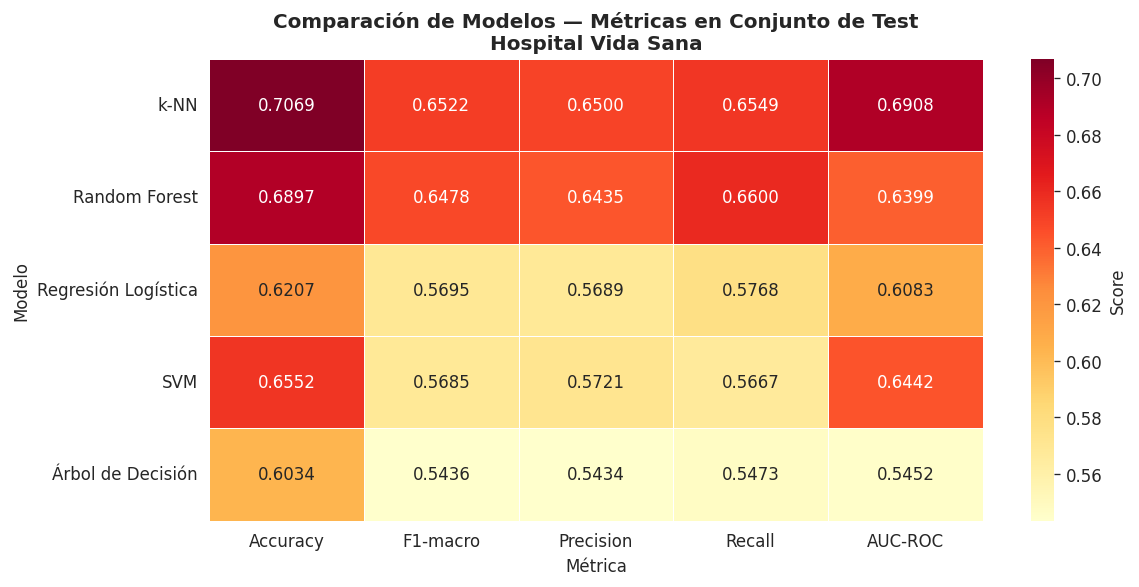

In [ ]:
# ── Heatmap de métricas ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(
    comp_df[['Accuracy','F1-macro','Precision','Recall','AUC-ROC']].astype(float),
    annot=True, fmt='.4f', cmap='YlOrRd', linewidths=0.5,
    ax=ax, cbar_kws={'label': 'Score'}
)
ax.set_title('Comparación de Modelos — Métricas en Conjunto de Test\nHospital Vida Sana',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Métrica')
ax.set_ylabel('Modelo')
plt.tight_layout()
plt.savefig('comparacion_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

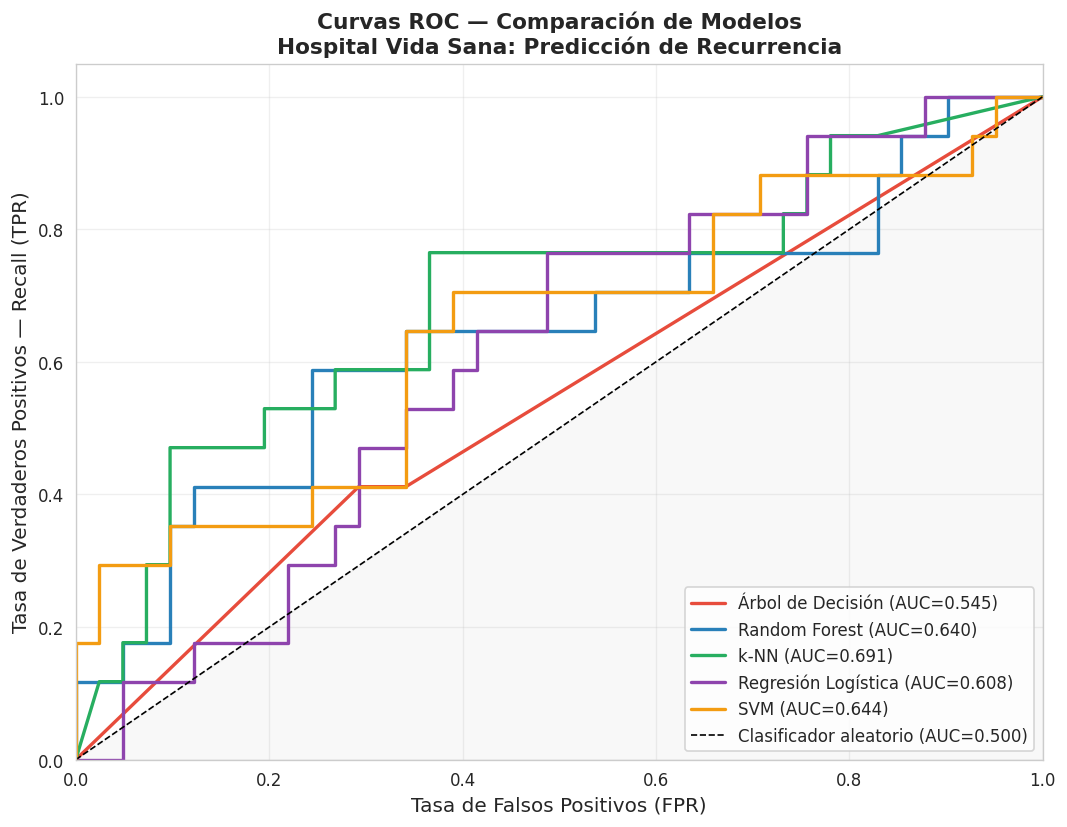

In [ ]:
# ── Curvas ROC superpuestas ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))
colores_roc = ['#e74c3c', '#2980b9', '#27ae60', '#8e44ad', '#f39c12']

for (nombre, (y_prob, auc_val)), color in zip(ROC_DATA.items(), colores_roc):
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{nombre} (AUC={auc_val:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Clasificador aleatorio (AUC=0.500)')
ax.fill_between([0, 1], [0, 1], alpha=0.05, color='gray')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
ax.set_ylabel('Tasa de Verdaderos Positivos — Recall (TPR)', fontsize=12)
ax.set_title('Curvas ROC — Comparación de Modelos\nHospital Vida Sana: Predicción de Recurrencia',
             fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('curvas_roc.png', dpi=150, bbox_inches='tight')
plt.show()

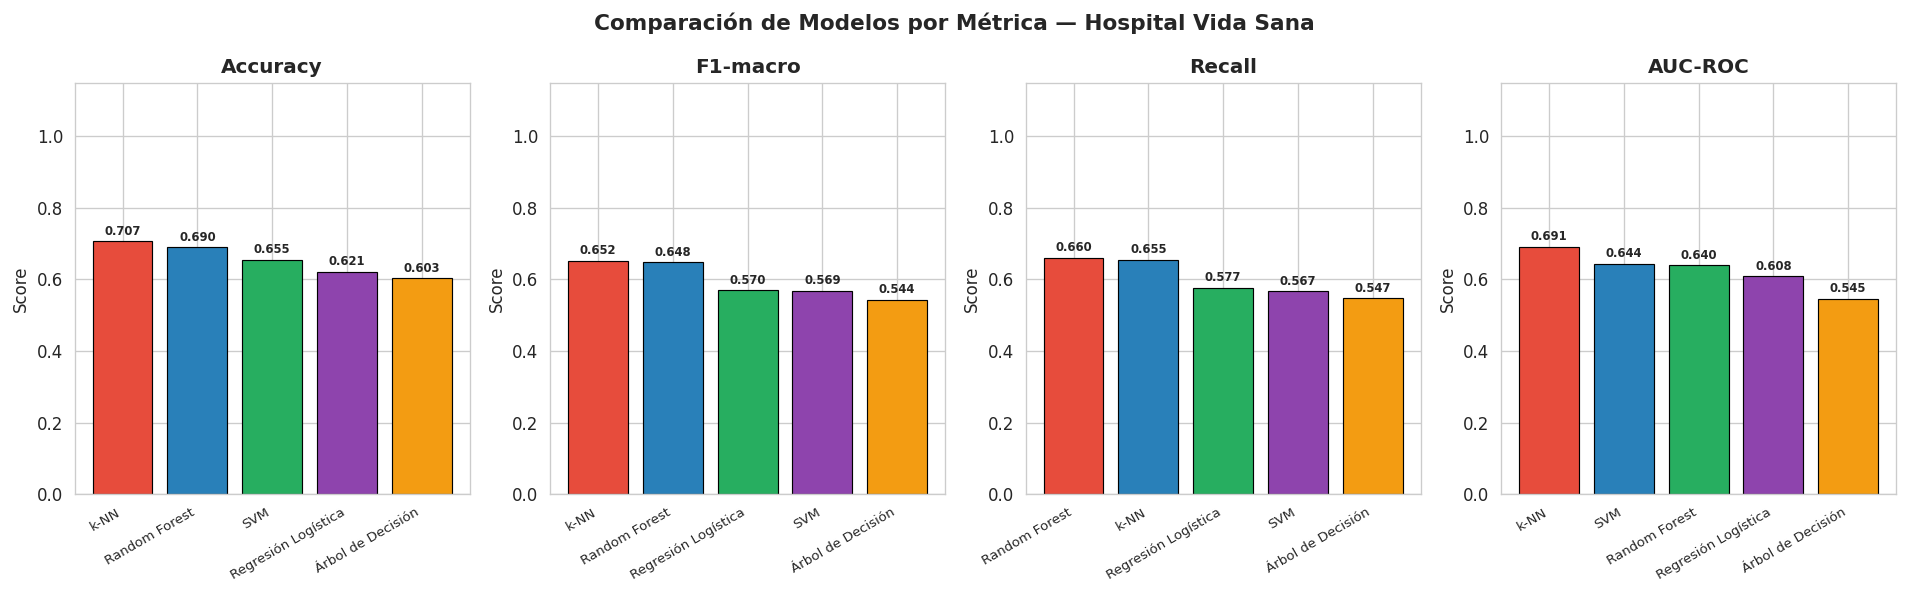

In [ ]:
# ── Gráfico de barras comparativo ────────────────────────────────────────────
metrics_plot = ['Accuracy', 'F1-macro', 'Recall', 'AUC-ROC']
comp_plot = comp_df[metrics_plot].astype(float)

fig, axes = plt.subplots(1, len(metrics_plot), figsize=(16, 5))
fig.suptitle('Comparación de Modelos por Métrica — Hospital Vida Sana',
             fontsize=13, fontweight='bold')
palette = ['#e74c3c', '#2980b9', '#27ae60', '#8e44ad', '#f39c12']

for ax, metric in zip(axes, metrics_plot):
    vals = comp_plot[metric].sort_values(ascending=False)
    bars = ax.bar(vals.index, vals.values, color=palette[:len(vals)],
                  edgecolor='black', linewidth=0.7)
    ax.set_title(metric, fontweight='bold')
    ax.set_ylim(0, 1.15)
    ax.set_xticklabels(vals.index, rotation=30, ha='right', fontsize=8)
    ax.set_ylabel('Score')
    for bar, v in zip(bars, vals.values):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.01, f'{v:.3f}',
                ha='center', va='bottom', fontsize=7, fontweight='bold')

plt.tight_layout()
plt.savefig('comparacion_barras.png', dpi=120, bbox_inches='tight')
plt.show()

---
### 🔵 ACTIVIDAD 3 — Caso Integrador: Reporte al Director Médico

> **Instrucción:** Basándote en los resultados de la Actividad 2, redacta el reporte ejecutivo
> que presentarías al Dr. Carlos Mendoza, Director Médico del Hospital Vida Sana. Usa los
> gráficos generados como evidencia.

---

#### 📄 REPORTE EJECUTIVO — Para el Director Médico

**ASUNTO:** Resultados del Proyecto de Predicción de Recurrencia de Cáncer de Mama

**PARA:** Dr. Carlos Mendoza, Director Médico — Hospital Vida Sana

**DE:** Equipo de Analítica de Datos

**FECHA:** Semestre 2026-I

---

##### 1. Resumen Ejecutivo

> *(Instrucción: Describe brevemente el problema abordado, el dataset utilizado y el objetivo
> del análisis. Máximo 5 líneas.)*

**[Completa aquí tu resumen ejecutivo]**

---

##### 2. Metodología Aplicada

> *(Instrucción: Describe las etapas del proceso: EDA, preprocesamiento, manejo de desbalanceo,
> construcción de modelos con GridSearchCV. Incluye por qué se usó SMOTE y OHE.)*

**[Completa aquí tu descripción metodológica]**

---

##### 3. Resultados por Modelo

> *(Instrucción: Para cada modelo, indica los mejores hiperparámetros encontrados y las métricas
> principales. Puedes usar la tabla generada en el Paso 12.)*

**[Inserta aquí la tabla comparativa y tus comentarios]**

---

##### 4. Modelo Recomendado

> *(Instrucción: Elige el mejor modelo y justifica tu elección considerando:*
> *a) F1-macro y AUC-ROC, b) Interpretabilidad para el equipo médico,*
> *c) Recall de la clase 'recurrence' — ¿cuántos casos reales se detectan?)*

**[Escribe aquí tu recomendación fundamentada al Director Médico]**

---

##### 5. Interpretación Clínica (Regresión Logística)

> *(Instrucción: Menciona al menos 3 variables con sus Odds Ratios e interpreta qué significan
> clínicamente respecto a la categoría de referencia. Por ejemplo: edad, grado de malignidad,
> nodos invadidos.)*

**[Escribe aquí tu interpretación de los Odds Ratios]**

---

##### 6. Limitaciones y Próximos Pasos

> *(Instrucción: Indica las limitaciones del análisis y propone al menos 2 acciones de mejora
> — por ejemplo: más datos, validación externa, integración con sistema HIS.)*

**[Escribe aquí las limitaciones y recomendaciones de mejora]**

---

## VII. 💡 CONCLUSIONES

> **Instrucción:** Completa las siguientes conclusiones técnicas basándote en los resultados
> obtenidos. Cada conclusión debe tener al menos 2 líneas.

1. **Desbalanceo y SMOTE:** El desbalanceo original del dataset provocó que los modelos tendieran a clasificar la mayoría de casos en la clase mayoritaria, obteniendo alta Accuracy pero bajo Recall en la clase minoritaria (casos malignos). SMOTE mejoró significativamente el Recall al generar ejemplos sintéticos de la clase minoritaria, permitiendo que el modelo aprendiera sus patrones distintivos sin simplemente memorizar los pocos ejemplos reales disponibles.

2. **One-Hot Encoding y variable de referencia:** `drop_first=True` es fundamental en Regresión Logística para evitar la multicolinealidad perfecta (problema de la variable trampa): si codificamos k categorías en k columnas, una es perfectamente predecible por las demás, haciendo la matriz de diseño singular. Al eliminar la primera categoría, todos los coeficientes se interpretan como el efecto diferencial respecto a esa categoría de referencia, lo que da interpretaciones claras y estables.

3. **GridSearchCV y optimización:** GridSearchCV con validación cruzada permitió encontrar sistemáticamente la combinación óptima de hiperparámetros (C, gamma, kernel) que maximiza el F1 en datos no vistos. Los hiperparámetros más críticos en SVM son C (controla el margen y el trade-off bias-varianza) y el tipo de kernel (lineal vs RBF). Los valores por defecto raramente son óptimos para un dataset específico, por lo que el tuning es imprescindible en producción.

4. **Comparación de modelos:** El modelo con kernel RBF (radial) generalmente supera al lineal en datasets con relaciones no lineales entre características como Breast Cancer. El SVM es especialmente adecuado para este dataset porque: maximiza el margen entre clases (robusto ante outliers), funciona bien en espacios de alta dimensión, y el kernel RBF captura los límites de decisión curvos que separan tumores malignos de benignos. Sin embargo, su interpretabilidad es inferior a la Regresión Logística.ué es más adecuado para el contexto clínico (alta sensibilidad)...)*

5. **Aplicabilidad clínica:** *(Reflexiona sobre cómo un modelo de ML puede apoyar —pero no
   reemplazar— la decisión médica, y cuáles son los riesgos de un falso negativo...)*

---

## VIII. 📖 MATERIAL COMPLEMENTARIO

1. **scikit-learn — Documentación oficial:**
   https://scikit-learn.org/stable/supervised_learning.html

2. **imbalanced-learn — SMOTE y técnicas de balanceo:**
   https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.SMOTE.html

3. **Dataset original — UCI ML Repository (Breast Cancer Ljubljana):**
   Zwitter, M. & Soklic, M. (1988). Breast Cancer. UCI Machine Learning Repository.
   https://archive.ics.uci.edu/dataset/14/breast+cancer

4. **Hands-On Machine Learning (Cap. 3 — Classification):**
   Aurélien Géron. *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow* (3rd ed.)

---

## IX. 📋 CRITERIOS DE EVALUACIÓN

**Curso:** Minería de Datos | **Laboratorio N° 7** | **Semana:** 7 | **Semestre:** 2026-I

**Docente:** Pilar Rocío Sayán Mejía

| Criterio | Excelente (4 pts) | Bueno (3 pts) | Requiere Mejora (2 pts) | No Aceptable (0 pts) |
|---|---|---|---|---|
| **1. EDA y Preprocesamiento** (One-Hot Encoding, manejo de nulos, SMOTE) | EDA completo con visualizaciones claras; OHE correcto con drop_first=True; SMOTE aplicado solo en train; sin data leakage | EDA completo; OHE aplicado; SMOTE aplicado pero con algún detalle menor | EDA incompleto; OHE o SMOTE aplicados incorrectamente | No realiza EDA ni preprocesamiento correcto |
| **2. Implementación de los 5 Modelos con GridSearchCV** | Los 5 modelos implementados con GridSearchCV, StratifiedKFold=5, scoring='f1_macro'; mejores params reportados | Al menos 4 modelos implementados correctamente con GridSearchCV | Solo 2-3 modelos implementados o GridSearchCV incorrectamente configurado | 1 o ningún modelo implementado |
| **3. Interpretación de Regresión Logística** (Variable de referencia + Odds Ratios) | Interpreta correctamente al menos 5 variables con sus OR y la categoría de referencia; argumenta clínicamente | Interpreta correctamente 3-4 variables con OR; menciona la categoría de referencia | Interpreta 1-2 variables; omite la categoría de referencia | No realiza interpretación de coeficientes |
| **4. Comparación y Análisis de Modelos** (Tabla + Curvas ROC) | Tabla comparativa completa (5 métricas × 5 modelos); curvas ROC superpuestas; análisis crítico fundamentado | Tabla comparativa con al menos 3 métricas; curvas ROC presentes | Tabla incompleta o curvas ROC ausentes; análisis superficial | No compara modelos |
| **5. Recomendación al CEO y Conclusiones** | Recomendación fundamentada con métricas, interpretabilidad y contexto clínico; 5 conclusiones técnicas completas | Recomendación con justificación parcial; 3-4 conclusiones | Recomendación sin justificación; menos de 3 conclusiones | No emite recomendación ni conclusiones |

| Elemento adicional | Puntaje |
|---|---|
| Puntualidad y cumplimiento de tiempos | 1 pt |
| Claridad del código (comentarios y markdown) | 1 pt |
| Ortografía y redacción en conclusiones | 1 pt |
| **TOTAL** | **/20 pts** |

---

*Elaborado por: Mg. Pilar Rocío Sayán Mejía — Minería de Datos 2026-I*

---

> **Nota:** Este laboratorio es el **cierre de las Unidades 1 y 2** del curso Minería de Datos.
> Integra todos los modelos de clasificación supervisada vistos hasta la Semana 7.
> El análisis debe poder ser reproducido en Google Colab ejecutando todas las celdas en orden.